<div>
  <h1>Nama: DIO IRSAPUTRA SIREGAR</h1>
  <h1>NIM : 1301213012</h1>
</div>

# Import Package

In [ ]:
#Import Package
import numpy as np
import pandas as pd
import scipy.optimize as sco
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from datetime import datetime
import time

# Mengumpulkan Dataset

##Dataset Saham

In [ ]:
# Daftar ticker saham
tickers = [
    'ACES.JK', 'ADRO.JK', 'AKRA.JK', "AMRT.JK", "ANTM.JK", "ARTO.JK", "ASII.JK",
    'BBCA.JK', 'BBNI.JK', 'BBRI.JK', 'BMRI.JK', 'BRPT.JK', 'CPIN.JK', 'GOTO.JK',
    'ICBP.JK', 'INCO.JK', 'INDF.JK', 'INKP.JK', 'KLBF.JK', 'MAPI.JK', 'MBMA.JK',
    'MDKA.JK', 'MEDC.JK', 'PGAS.JK', 'PGEO.JK', 'PTBA.JK', 'SMGR.JK', 'TLKM.JK',
    'UNTR.JK', 'UNVR.JK',
]


# Mengunduh harga penutupan saham disesuaikan (Close)
data = yf.download(tickers, start='2014-11-04', end='2022-11-04', rounding=True, interval="1wk")['Close']
data



/tmp/ipython-input-3463683197.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2014-11-04', end='2022-11-04', rounding=True, interval="1wk")['Close']
[*********************100%***********************]  30 of 30 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['MBMA.JK', 'PGEO.JK']: YFPricesMissingError('possibly delisted; no price data found  (1wk 2014-11-04 -> 2022-11-04) (Yahoo error = "Data doesn\'t exist for startDate = 1415034000, endDate = 1667494800")')


Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ARTO.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,...,MBMA.JK,MDKA.JK,MEDC.JK,PGAS.JK,PGEO.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
Date,,,,,,,,,,,,,,,,,,,,,
2014-11-03,576.70,423.87,581.09,471.24,633.21,NaN,4178.91,2077.15,2002.62,1232.82,...,NaN,NaN,602.73,3362.29,NaN,732.50,11562.96,1659.09,9071.98,4341.78
2014-11-10,584.05,387.10,570.13,471.24,633.21,NaN,4314.20,2113.95,2055.09,1282.02,...,NaN,NaN,605.19,3447.77,NaN,698.94,12073.09,1738.39,9240.43,4436.48
2014-11-17,598.74,416.13,564.05,466.75,663.68,NaN,4178.91,2179.37,2020.11,1293.59,...,NaN,NaN,601.91,3504.76,NaN,747.09,12167.56,1754.26,8795.25,4582.18
2014-11-24,591.39,418.07,565.87,471.24,663.68,NaN,4284.13,2142.57,2107.56,1334.11,...,NaN,NaN,612.56,3390.78,NaN,767.52,12091.99,1792.32,8819.32,4633.18
2014-12-01,580.37,433.55,550.66,457.78,653.52,NaN,4269.10,2183.46,2160.03,1328.32,...,NaN,NaN,597.82,3419.27,NaN,780.65,12507.65,1801.84,8506.49,4614.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-03,521.71,2635.50,1083.00,2256.77,1633.32,6775.0,4850.72,7520.43,3684.25,3627.54,...,NaN,3890.0,857.96,1295.79,NaN,2317.09,6527.86,3646.73,21410.20,4262.64
2022-10-10,449.01,2514.55,1142.51,2431.12,1536.25,5025.0,4757.08,7566.29,3537.30,3488.65,...,NaN,3660.0,921.86,1329.02,NaN,2284.68,6505.27,3596.43,22439.86,4236.22
2022-10-17,457.57,2520.91,1138.54,2547.34,1519.37,5425.0,4992.97,7933.14,3778.72,3619.37,...,NaN,3740.0,930.98,1380.70,NaN,2068.63,6866.67,3655.11,21276.32,4667.77


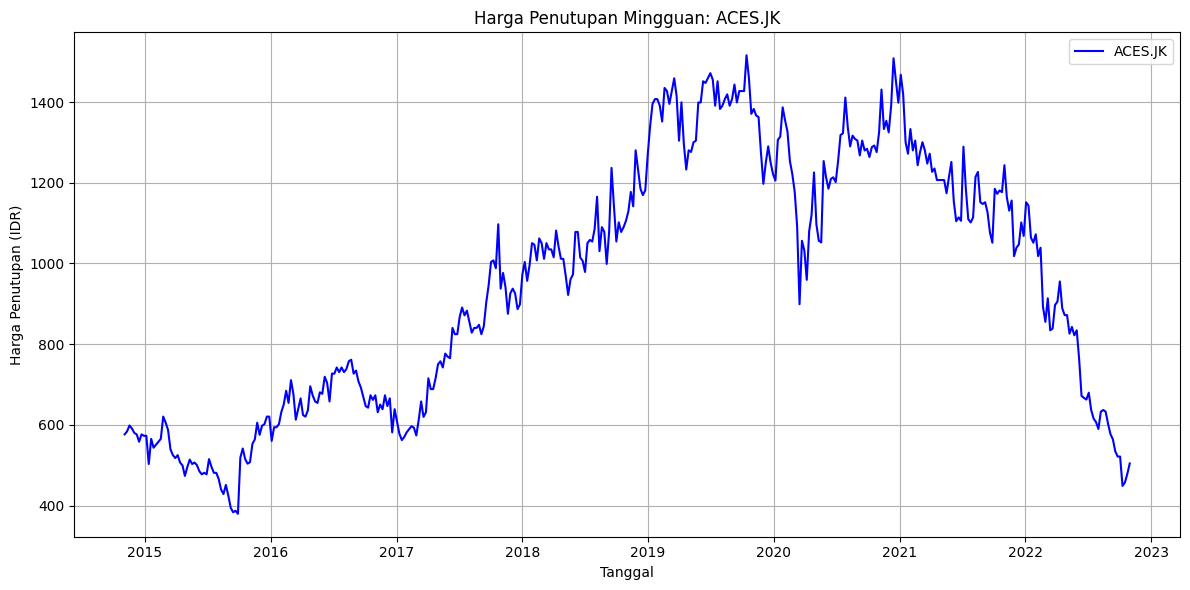

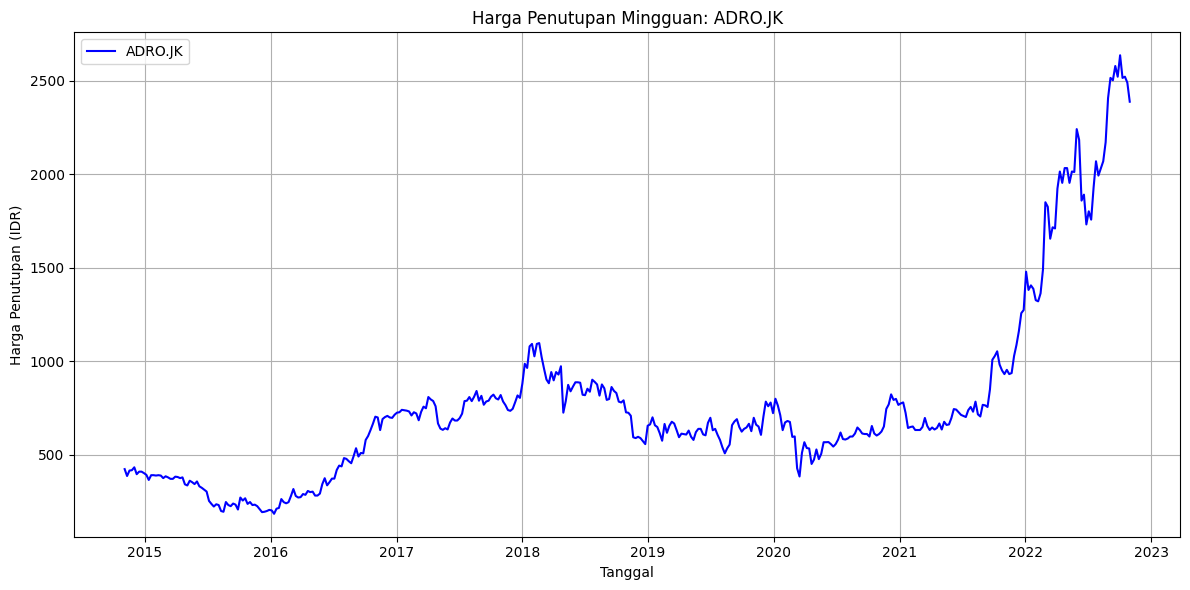

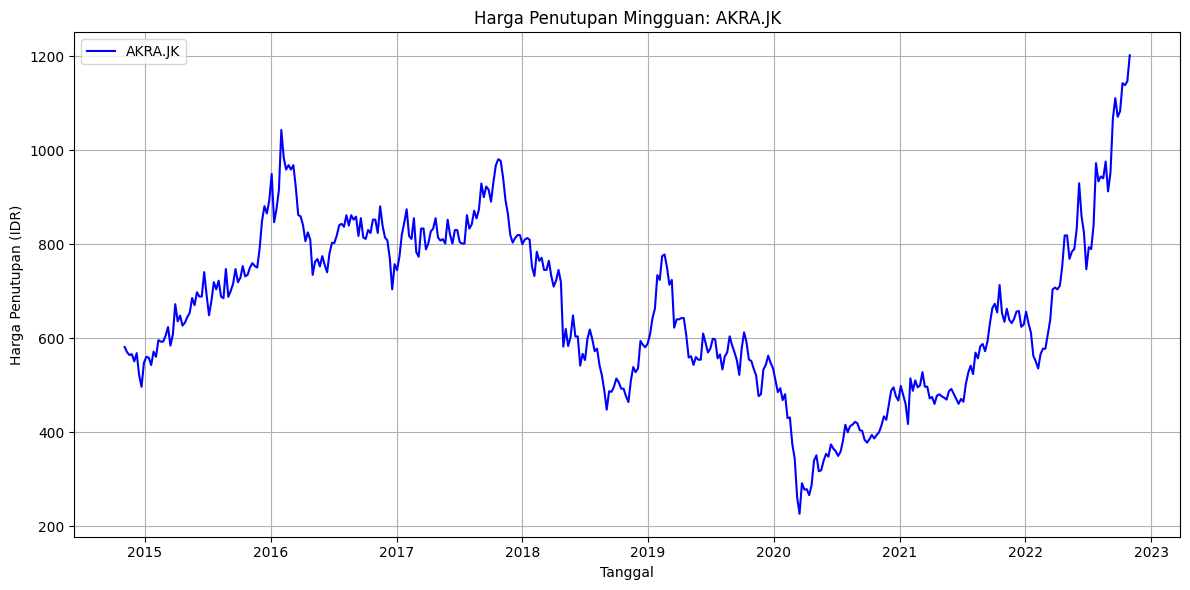

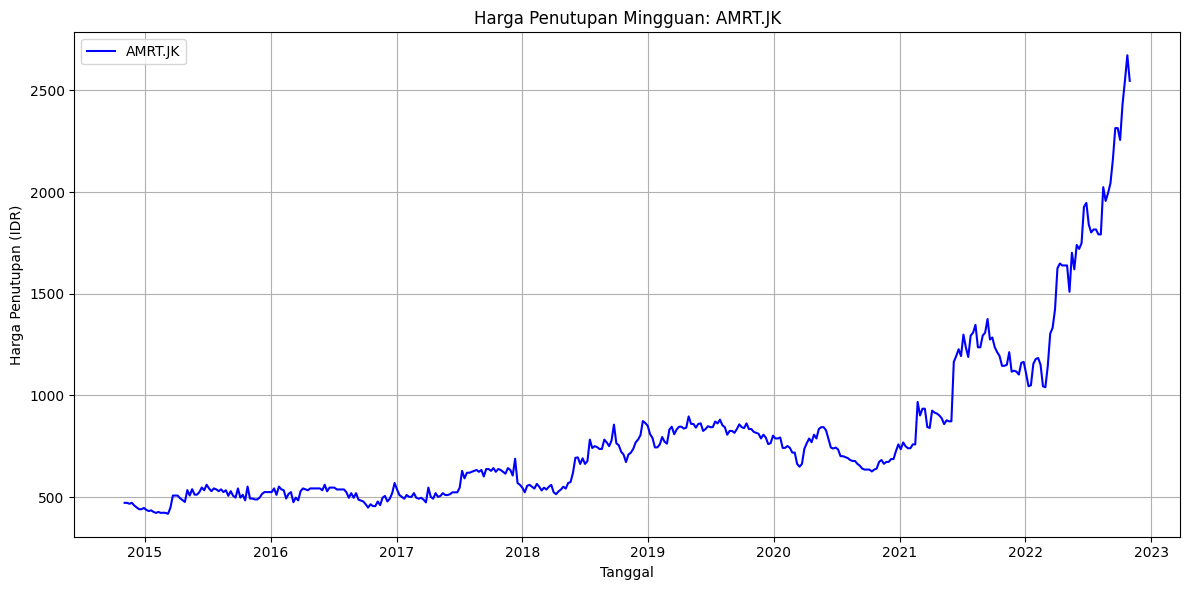

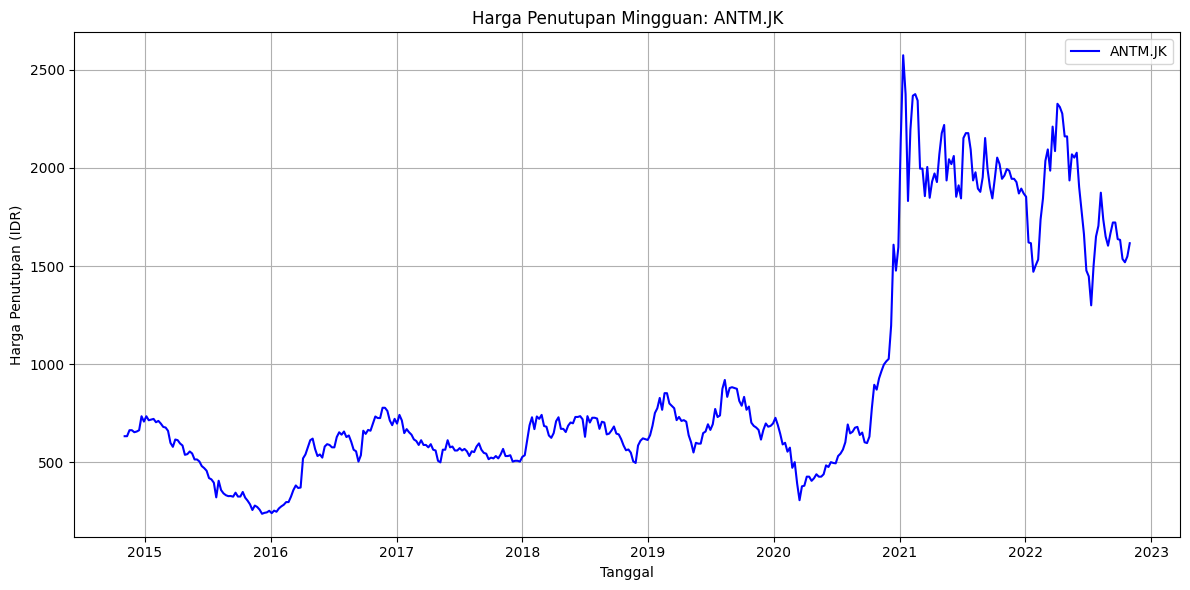

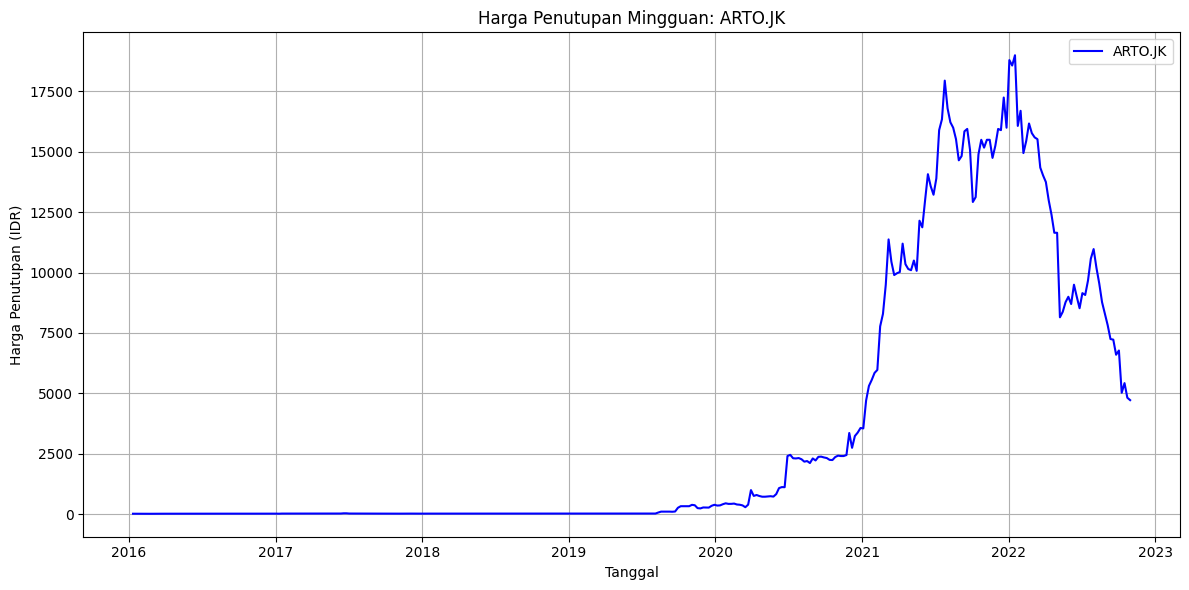

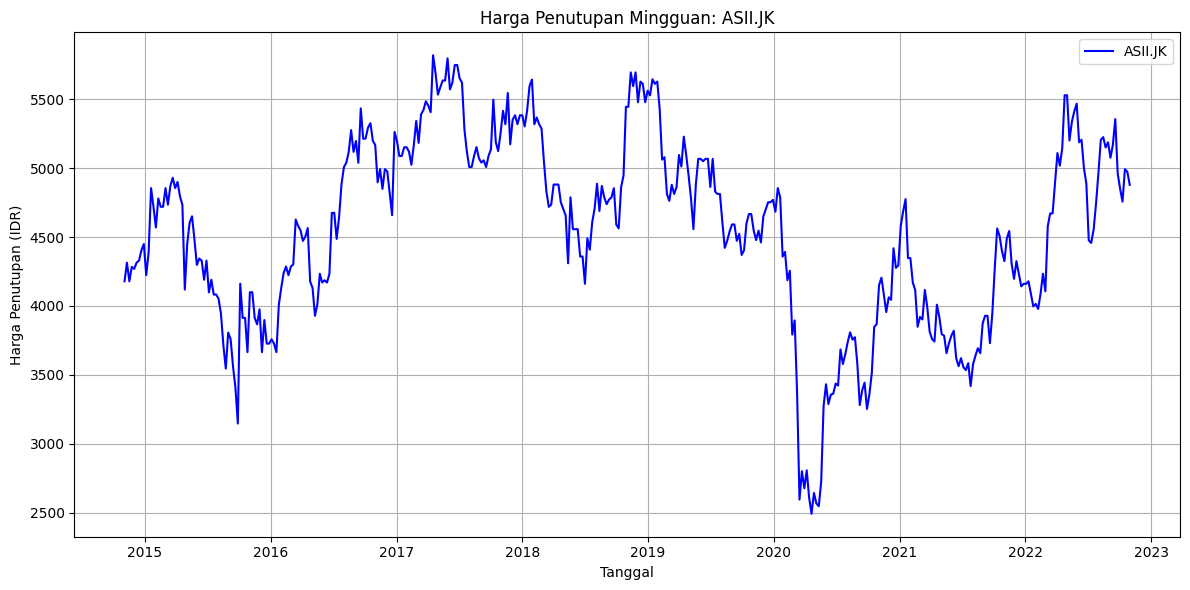

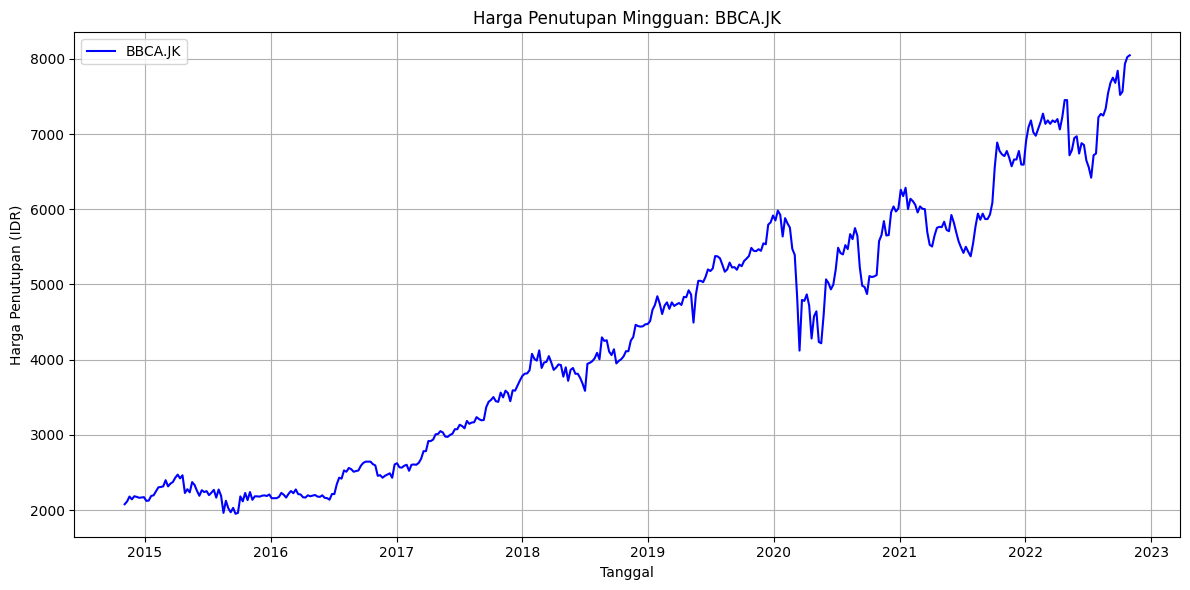

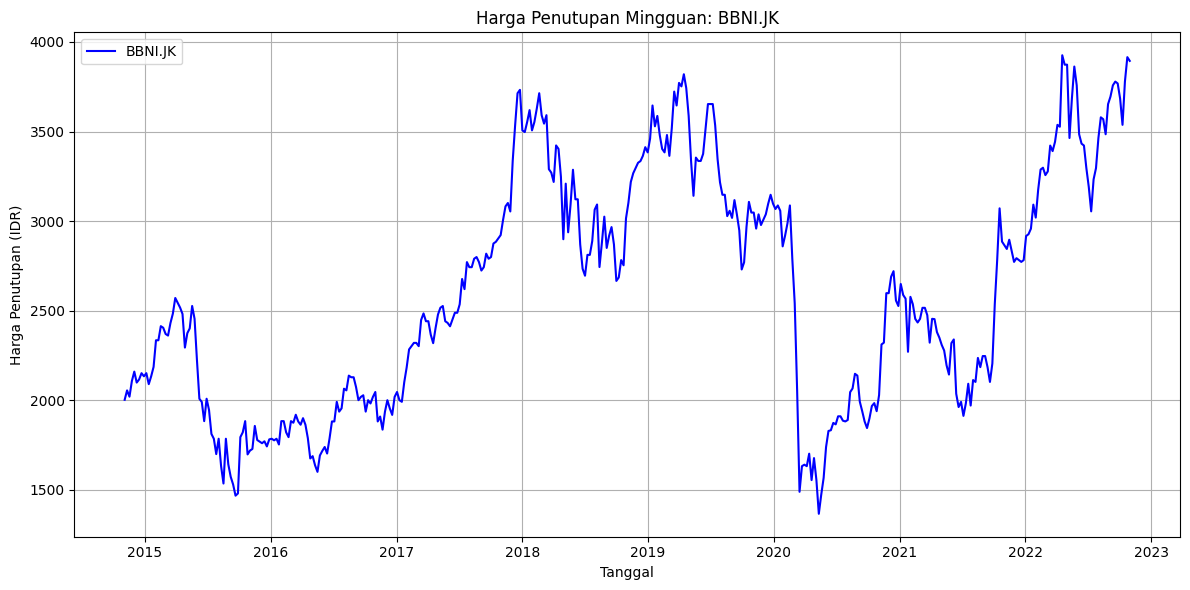

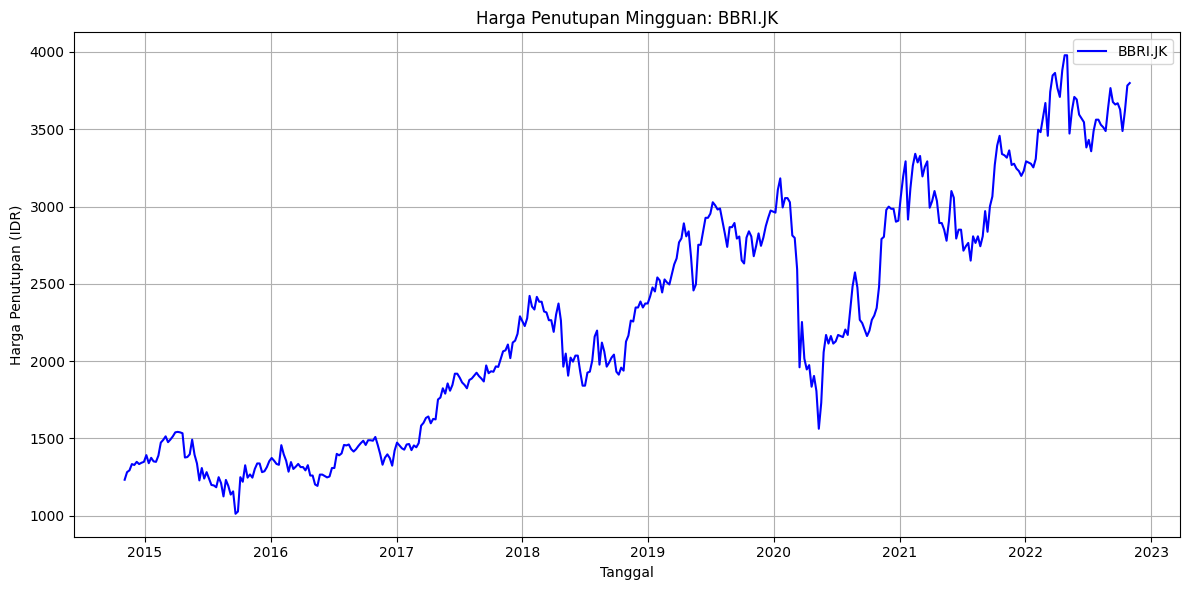

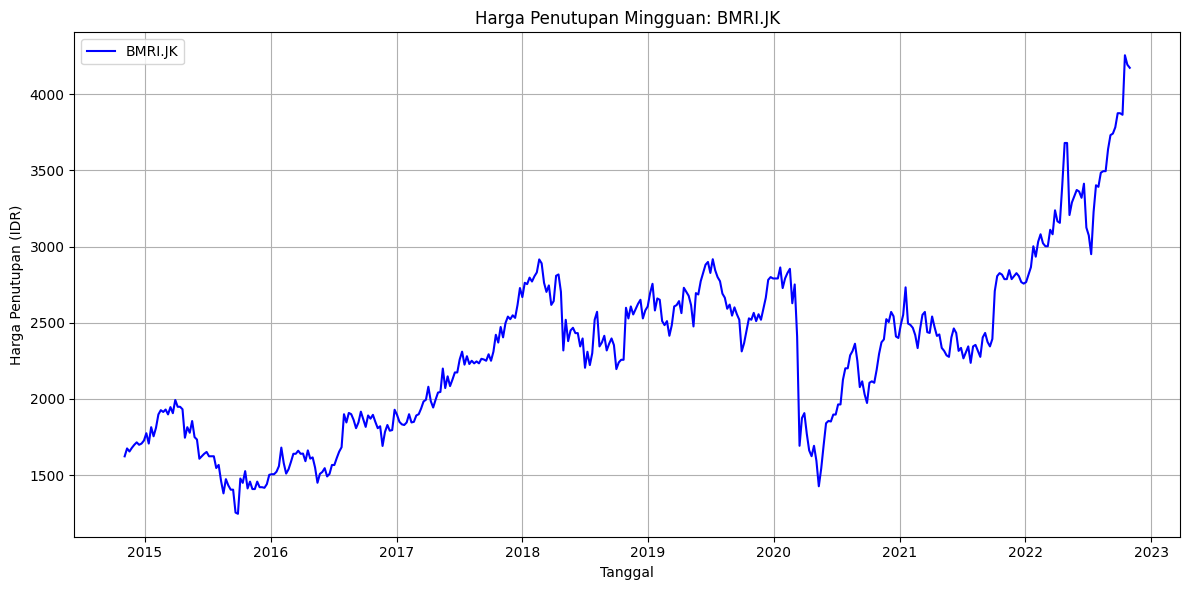

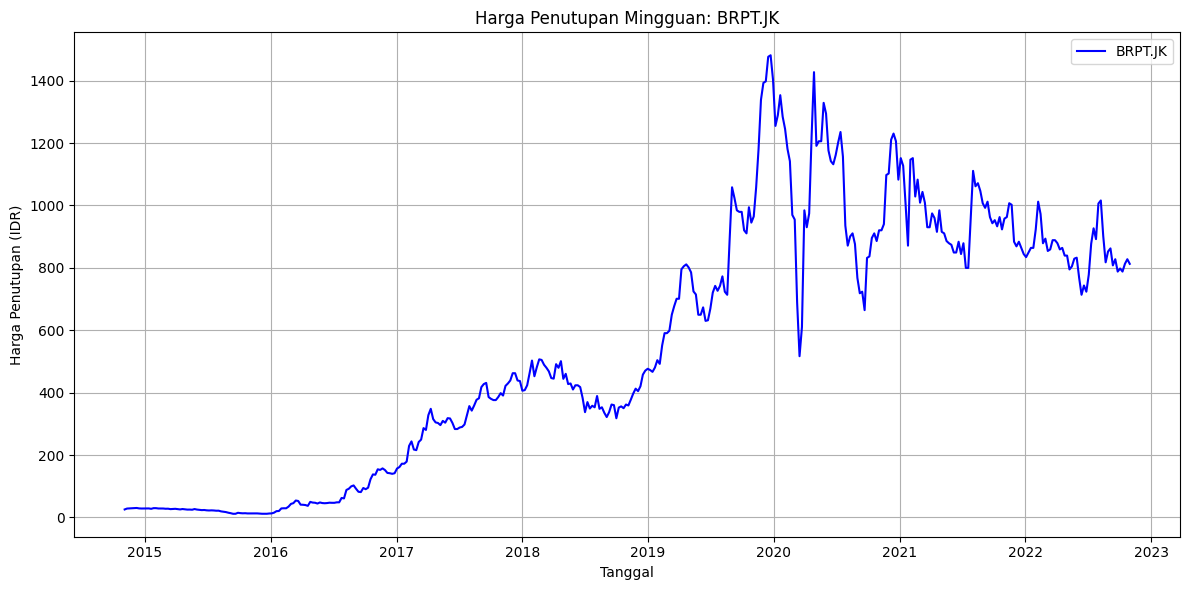

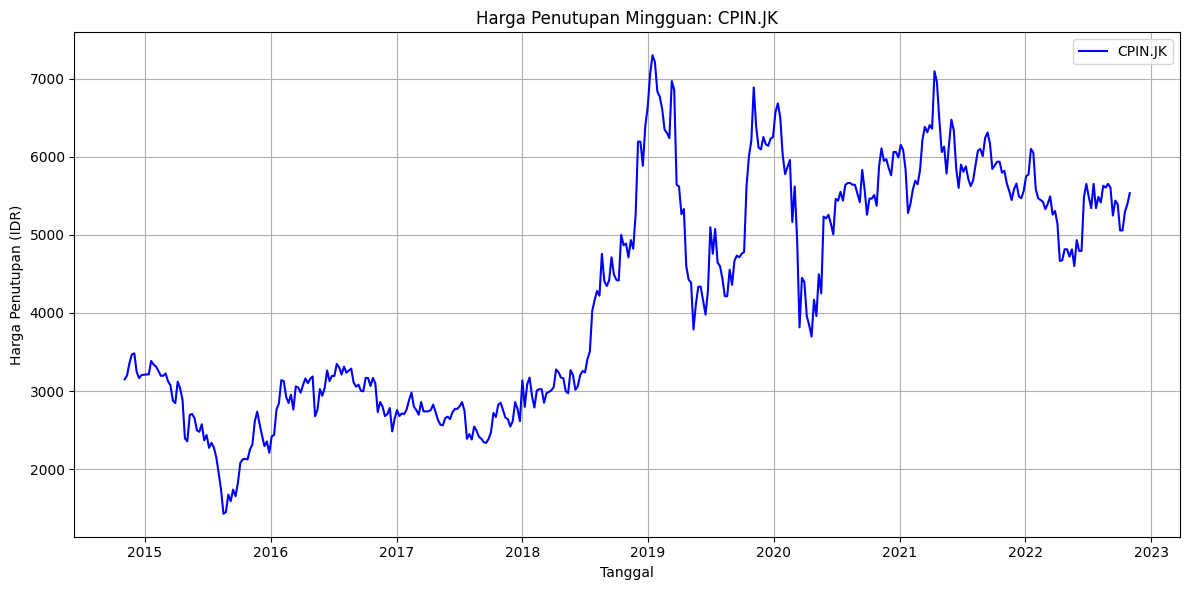

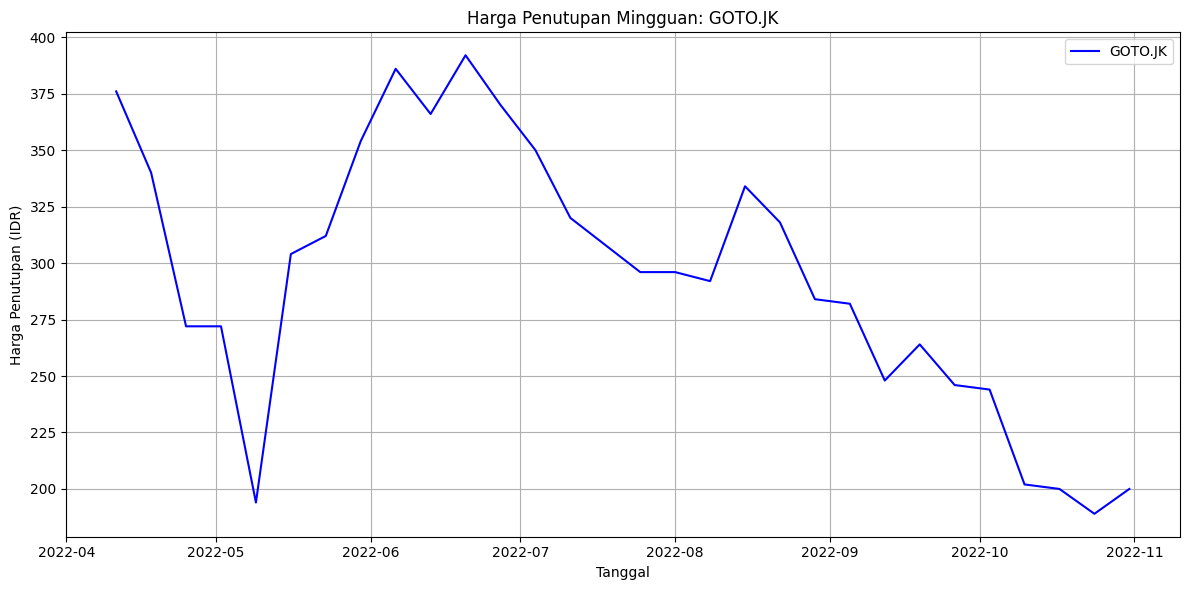

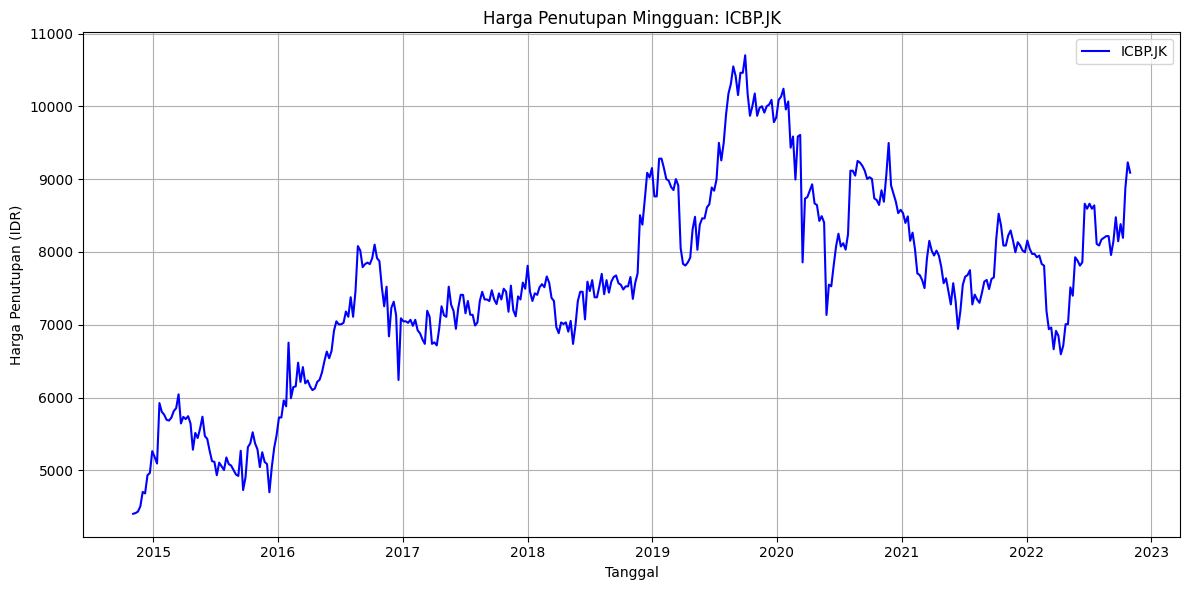

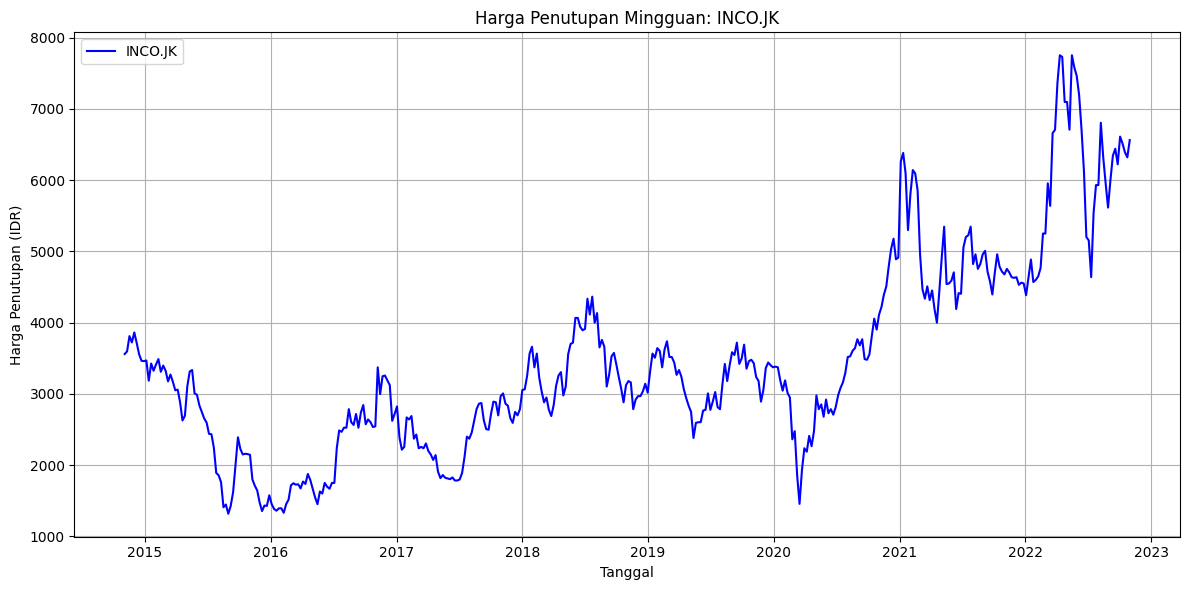

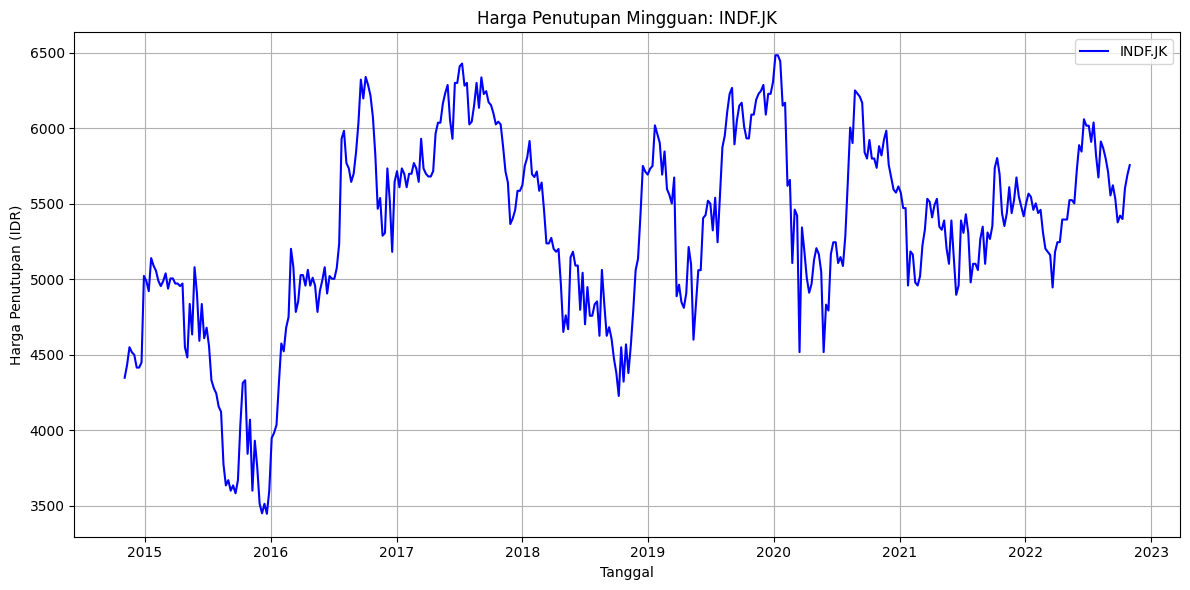

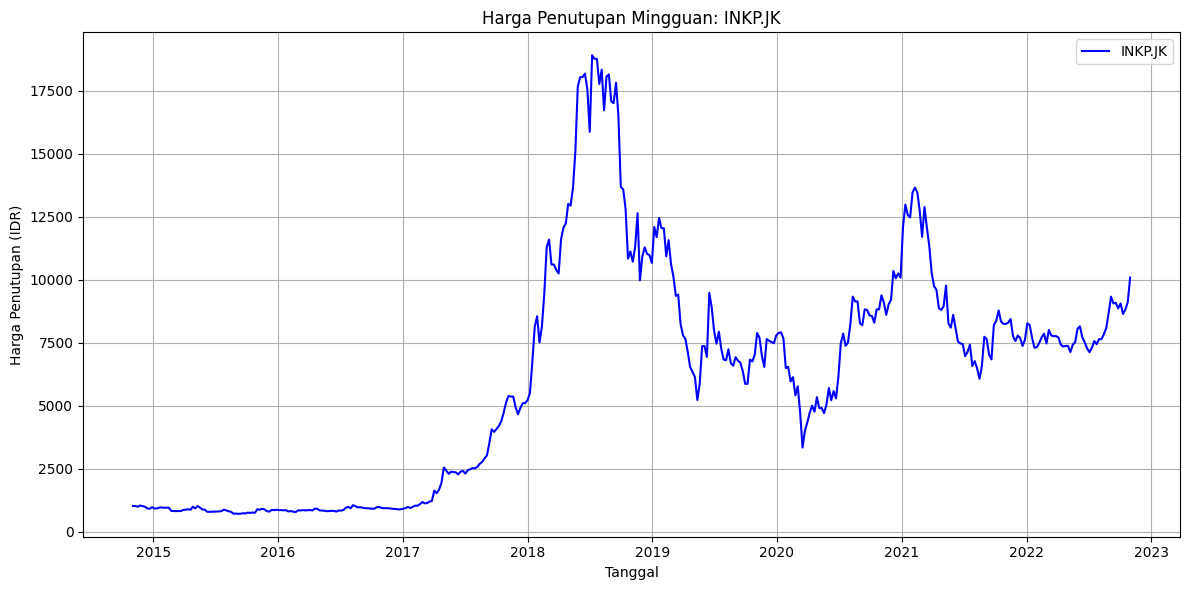

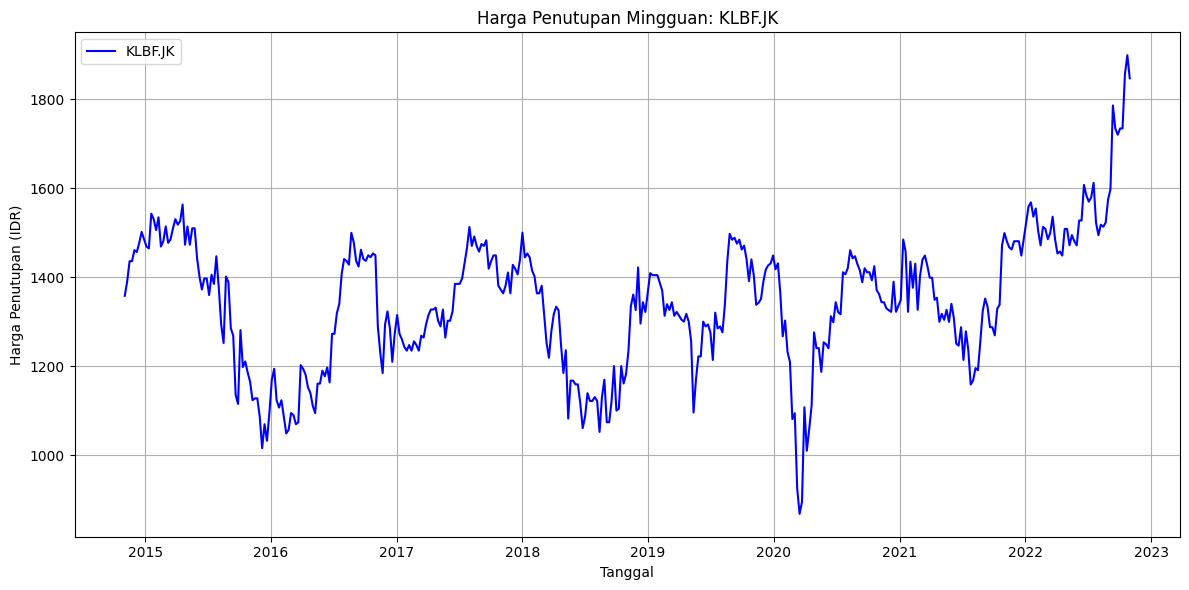

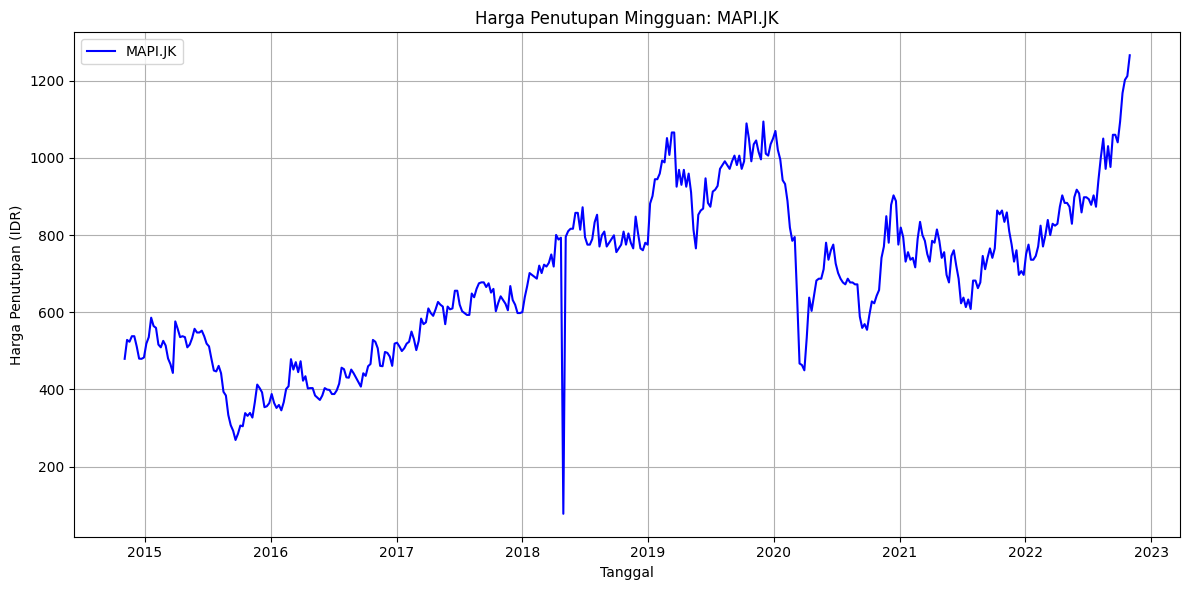

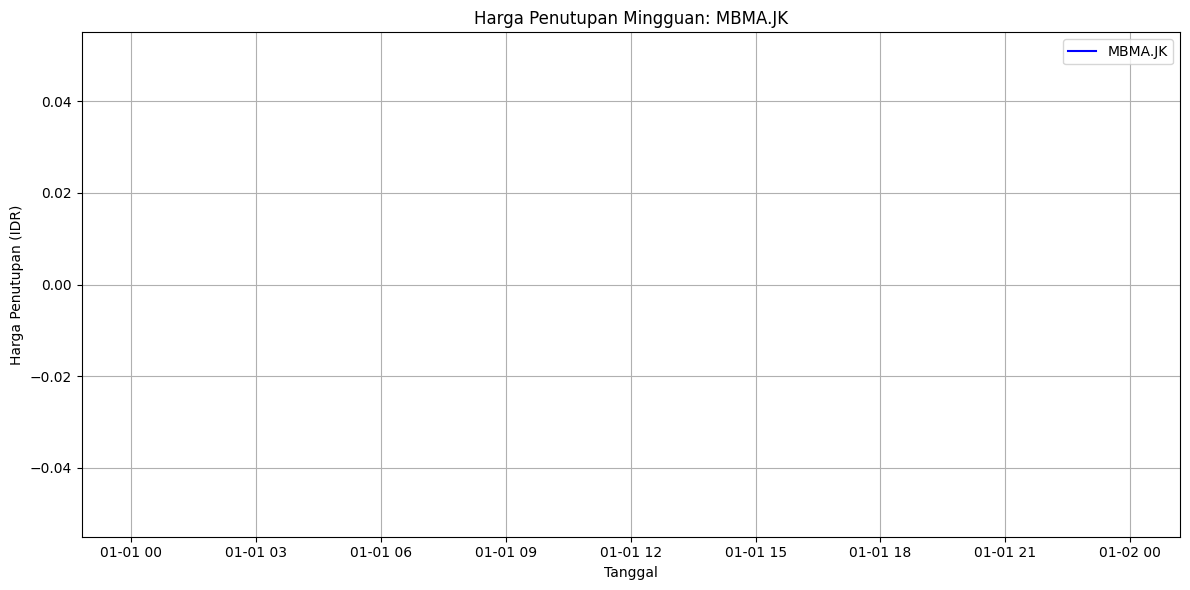

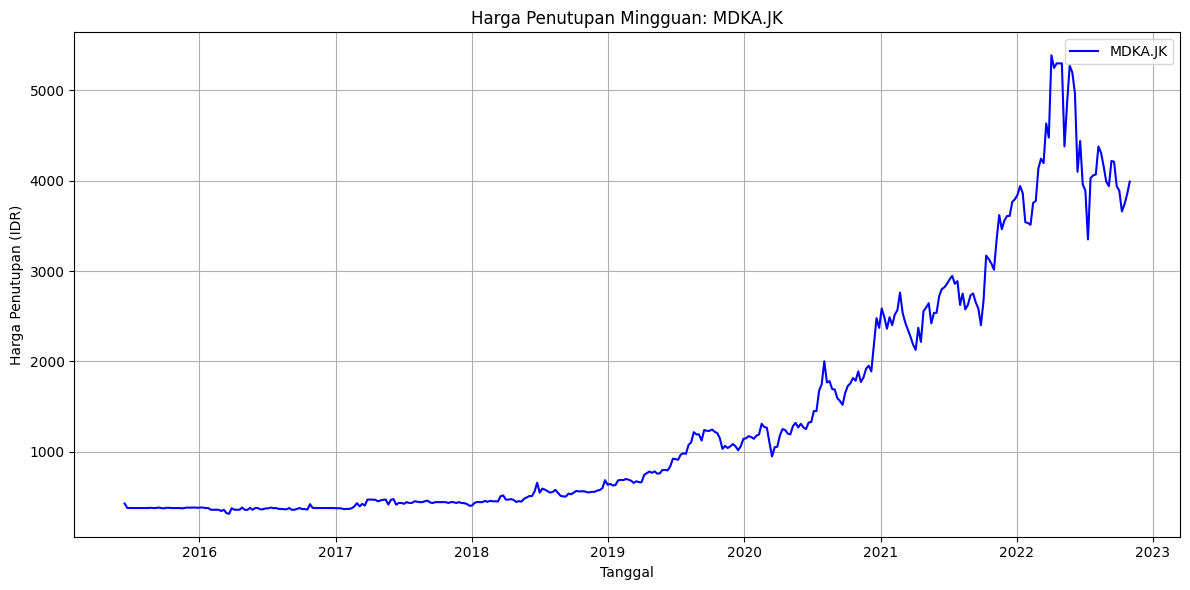

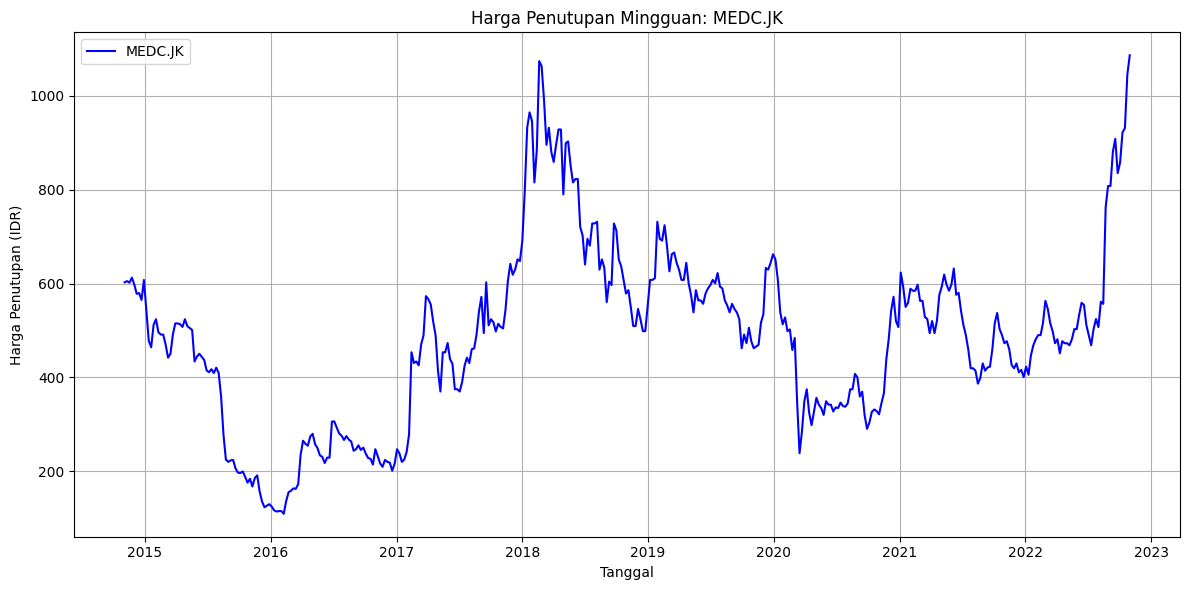

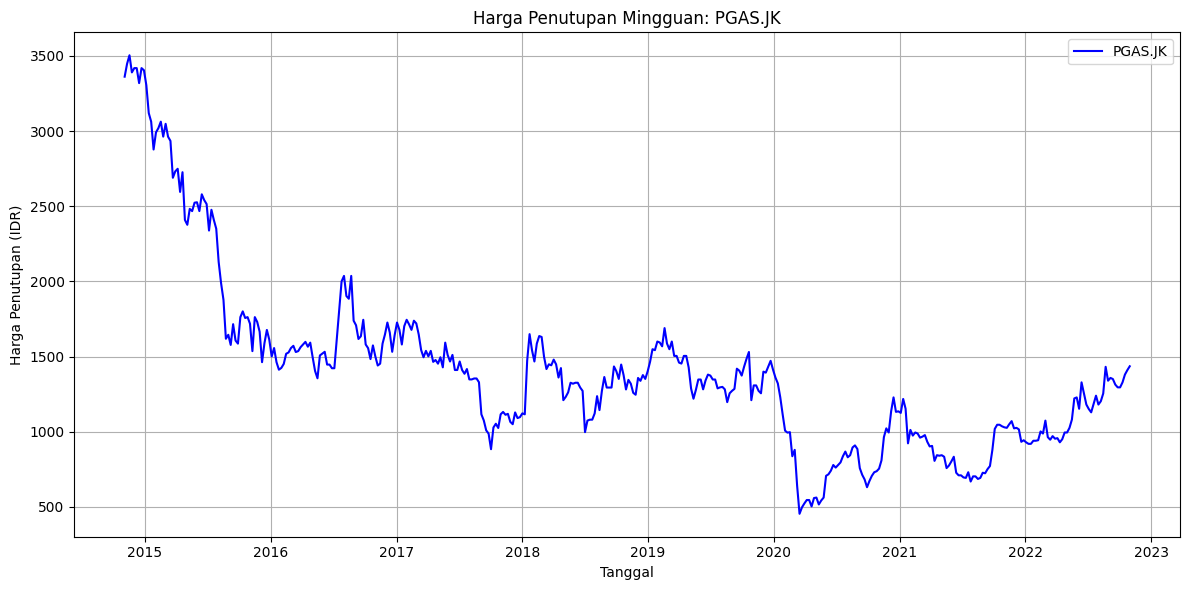

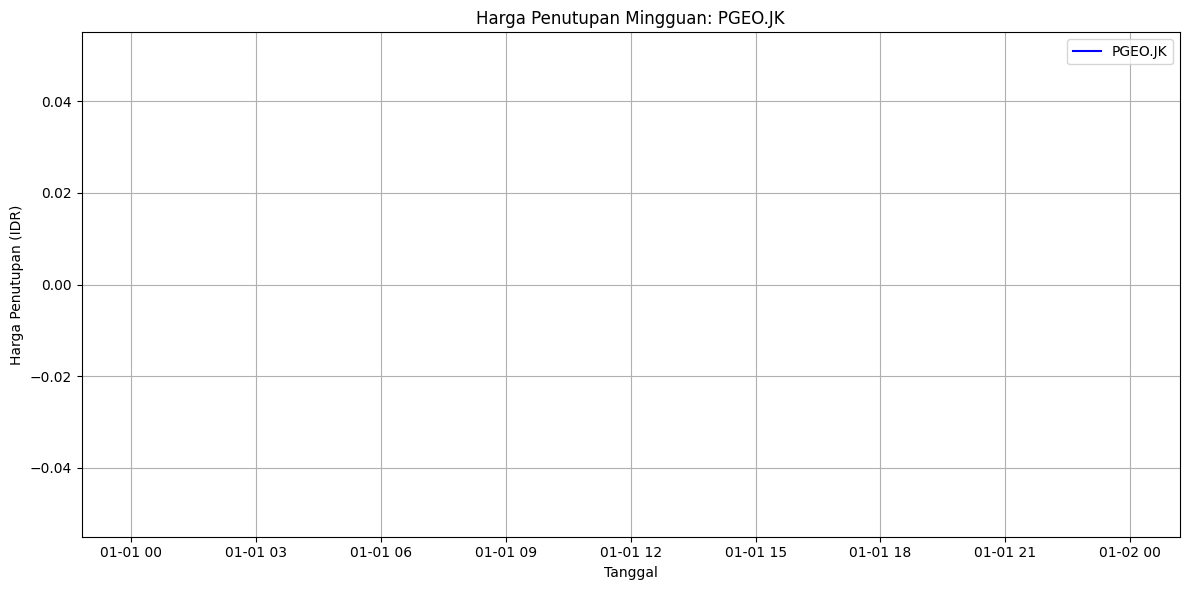

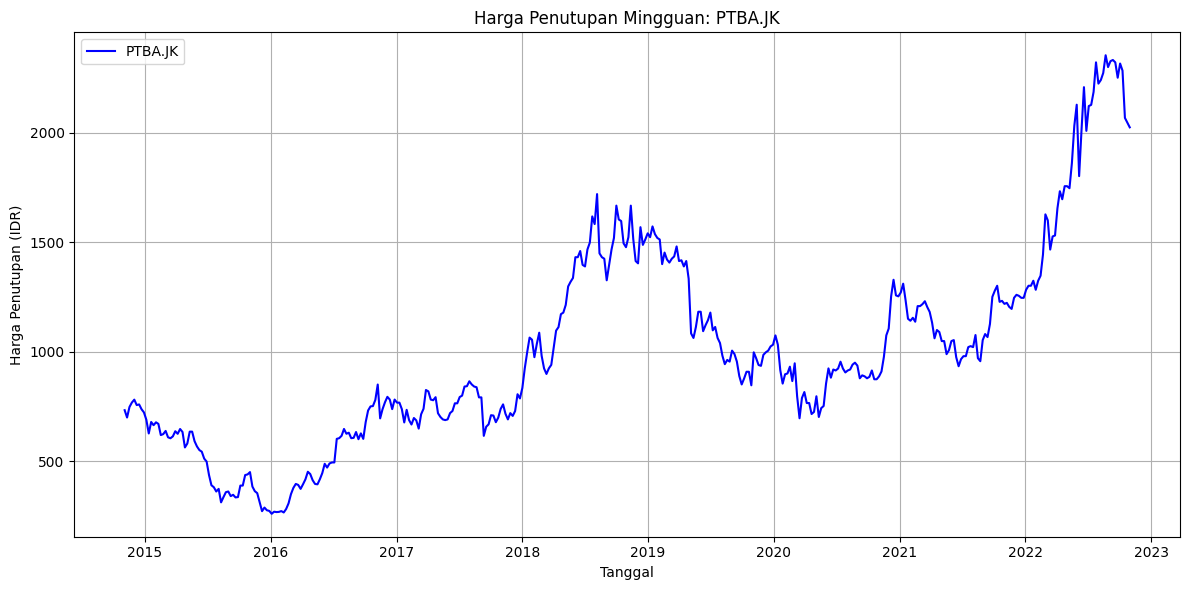

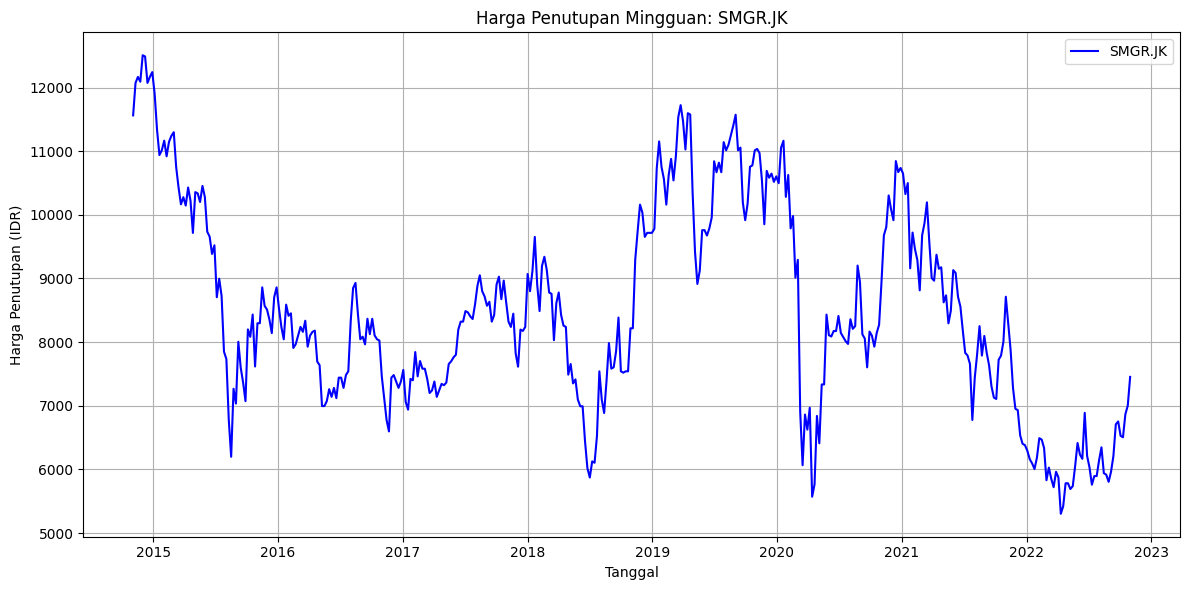

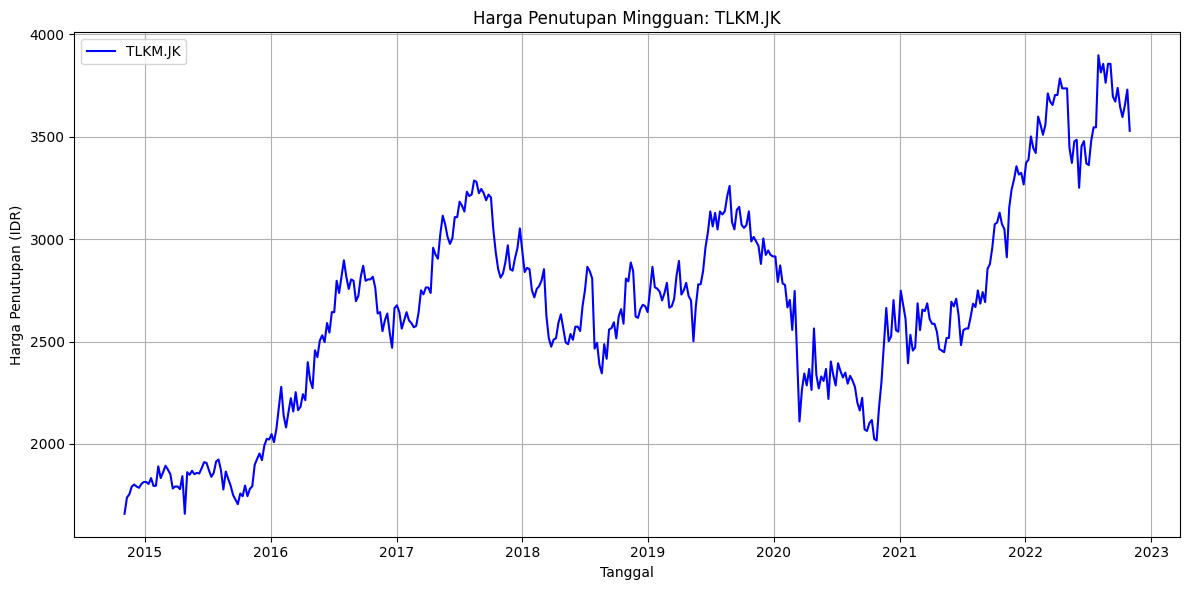

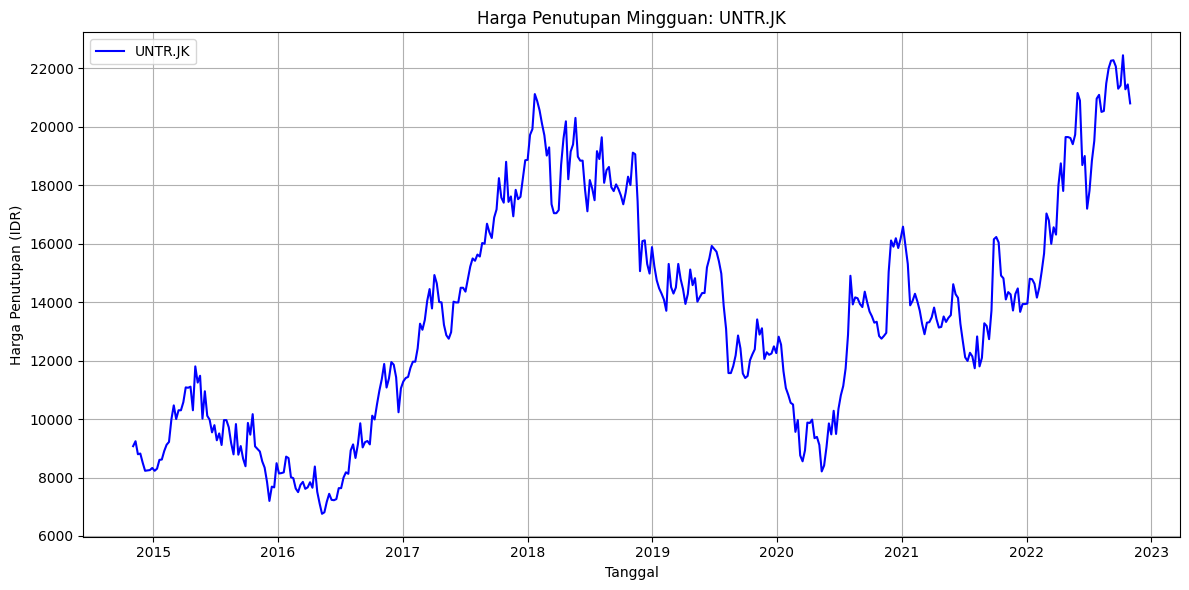

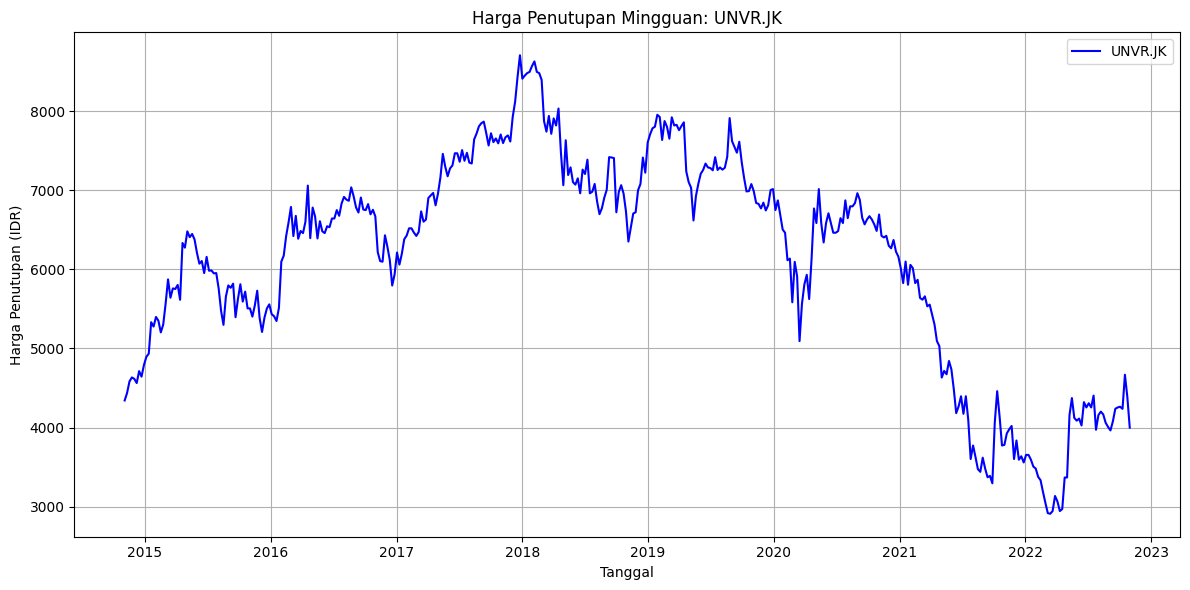

In [ ]:
# Plot harga penutupan mingguan
for ticker in tickers:
    if ticker in data.columns:
        plt.figure(figsize=(12, 6))
        plt.plot(data.index, data[ticker], label=f'{ticker}', color='blue')
        plt.title(f'Harga Penutupan Mingguan: {ticker}')
        plt.xlabel('Tanggal')
        plt.ylabel('Harga Penutupan (IDR)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

##Dataset ESG

In [ ]:
# ESG Score
esg_scores = {
    'ACES.JK': 19.65, 'ADRO.JK': 42.72, 'AKRA.JK': 23.79, "AMRT.JK": 31.93, "ANTM.JK": 42.06,
    "ASII.JK": 35.60, 'BBCA.JK': 21.51, 'BBNI.JK': 23.17, 'BBRI.JK': 17.83,
    'BMRI.JK': 27.64, 'BRPT.JK': 24.21, 'CPIN.JK': 44.48, 'ICBP.JK': 34.80,
    'INCO.JK': 29.41, 'INDF.JK': 36.06, 'INKP.JK': 26.44, 'KLBF.JK': 33.27, 'MAPI.JK': 20.31,
    'MEDC.JK': 29.08, 'PGAS.JK': 26.32,
    'PTBA.JK': 33.87, 'SMGR.JK': 23.05, 'TLKM.JK': 28.18, 'UNTR.JK': 38.81, 'UNVR.JK': 18.21,
}

# Konversi ke DataFrame
esg_df = pd.DataFrame(list(esg_scores.items()), columns=['Ticker', 'ESG_Score'])
# Mengubah data menjadi CSV
csv_file_path = 'stock_data_esg.csv'
esg_df.to_csv(csv_file_path)
esg_df


,Ticker,ESG_Score
0,ACES.JK,19.65
1,ADRO.JK,42.72
2,AKRA.JK,23.79
3,AMRT.JK,31.93
4,ANTM.JK,42.06
5,ASII.JK,35.60
6,BBCA.JK,21.51
7,BBNI.JK,23.17
8,BBRI.JK,17.83
9,BMRI.JK,27.64


In [ ]:
#Kategorikan berdasarkan ESG Score
categories = {
    '0-10': esg_df[esg_df['ESG_Score'] <= 10],
    '11-20': esg_df[(esg_df['ESG_Score'] > 10) & (esg_df['ESG_Score'] <= 20)],
    '21-30': esg_df[(esg_df['ESG_Score'] > 20) & (esg_df['ESG_Score'] <= 30)],
    '31-40': esg_df[(esg_df['ESG_Score'] > 30) & (esg_df['ESG_Score'] <= 40)],
    '>41': esg_df[esg_df['ESG_Score'] > 41],
}

categories

{'0-10': Empty DataFrame
 Columns: [Ticker, ESG_Score]
 Index: [],
 '11-20':      Ticker  ESG_Score
 0   ACES.JK      19.65
 8   BBRI.JK      17.83
 24  UNVR.JK      18.21,
 '21-30':      Ticker  ESG_Score
 2   AKRA.JK      23.79
 6   BBCA.JK      21.51
 7   BBNI.JK      23.17
 9   BMRI.JK      27.64
 10  BRPT.JK      24.21
 13  INCO.JK      29.41
 15  INKP.JK      26.44
 17  MAPI.JK      20.31
 18  MEDC.JK      29.08
 19  PGAS.JK      26.32
 21  SMGR.JK      23.05
 22  TLKM.JK      28.18,
 '31-40':      Ticker  ESG_Score
 3   AMRT.JK      31.93
 5   ASII.JK      35.60
 12  ICBP.JK      34.80
 14  INDF.JK      36.06
 16  KLBF.JK      33.27
 20  PTBA.JK      33.87
 23  UNTR.JK      38.81,
 '>41':      Ticker  ESG_Score
 1   ADRO.JK      42.72
 4   ANTM.JK      42.06
 11  CPIN.JK      44.48}

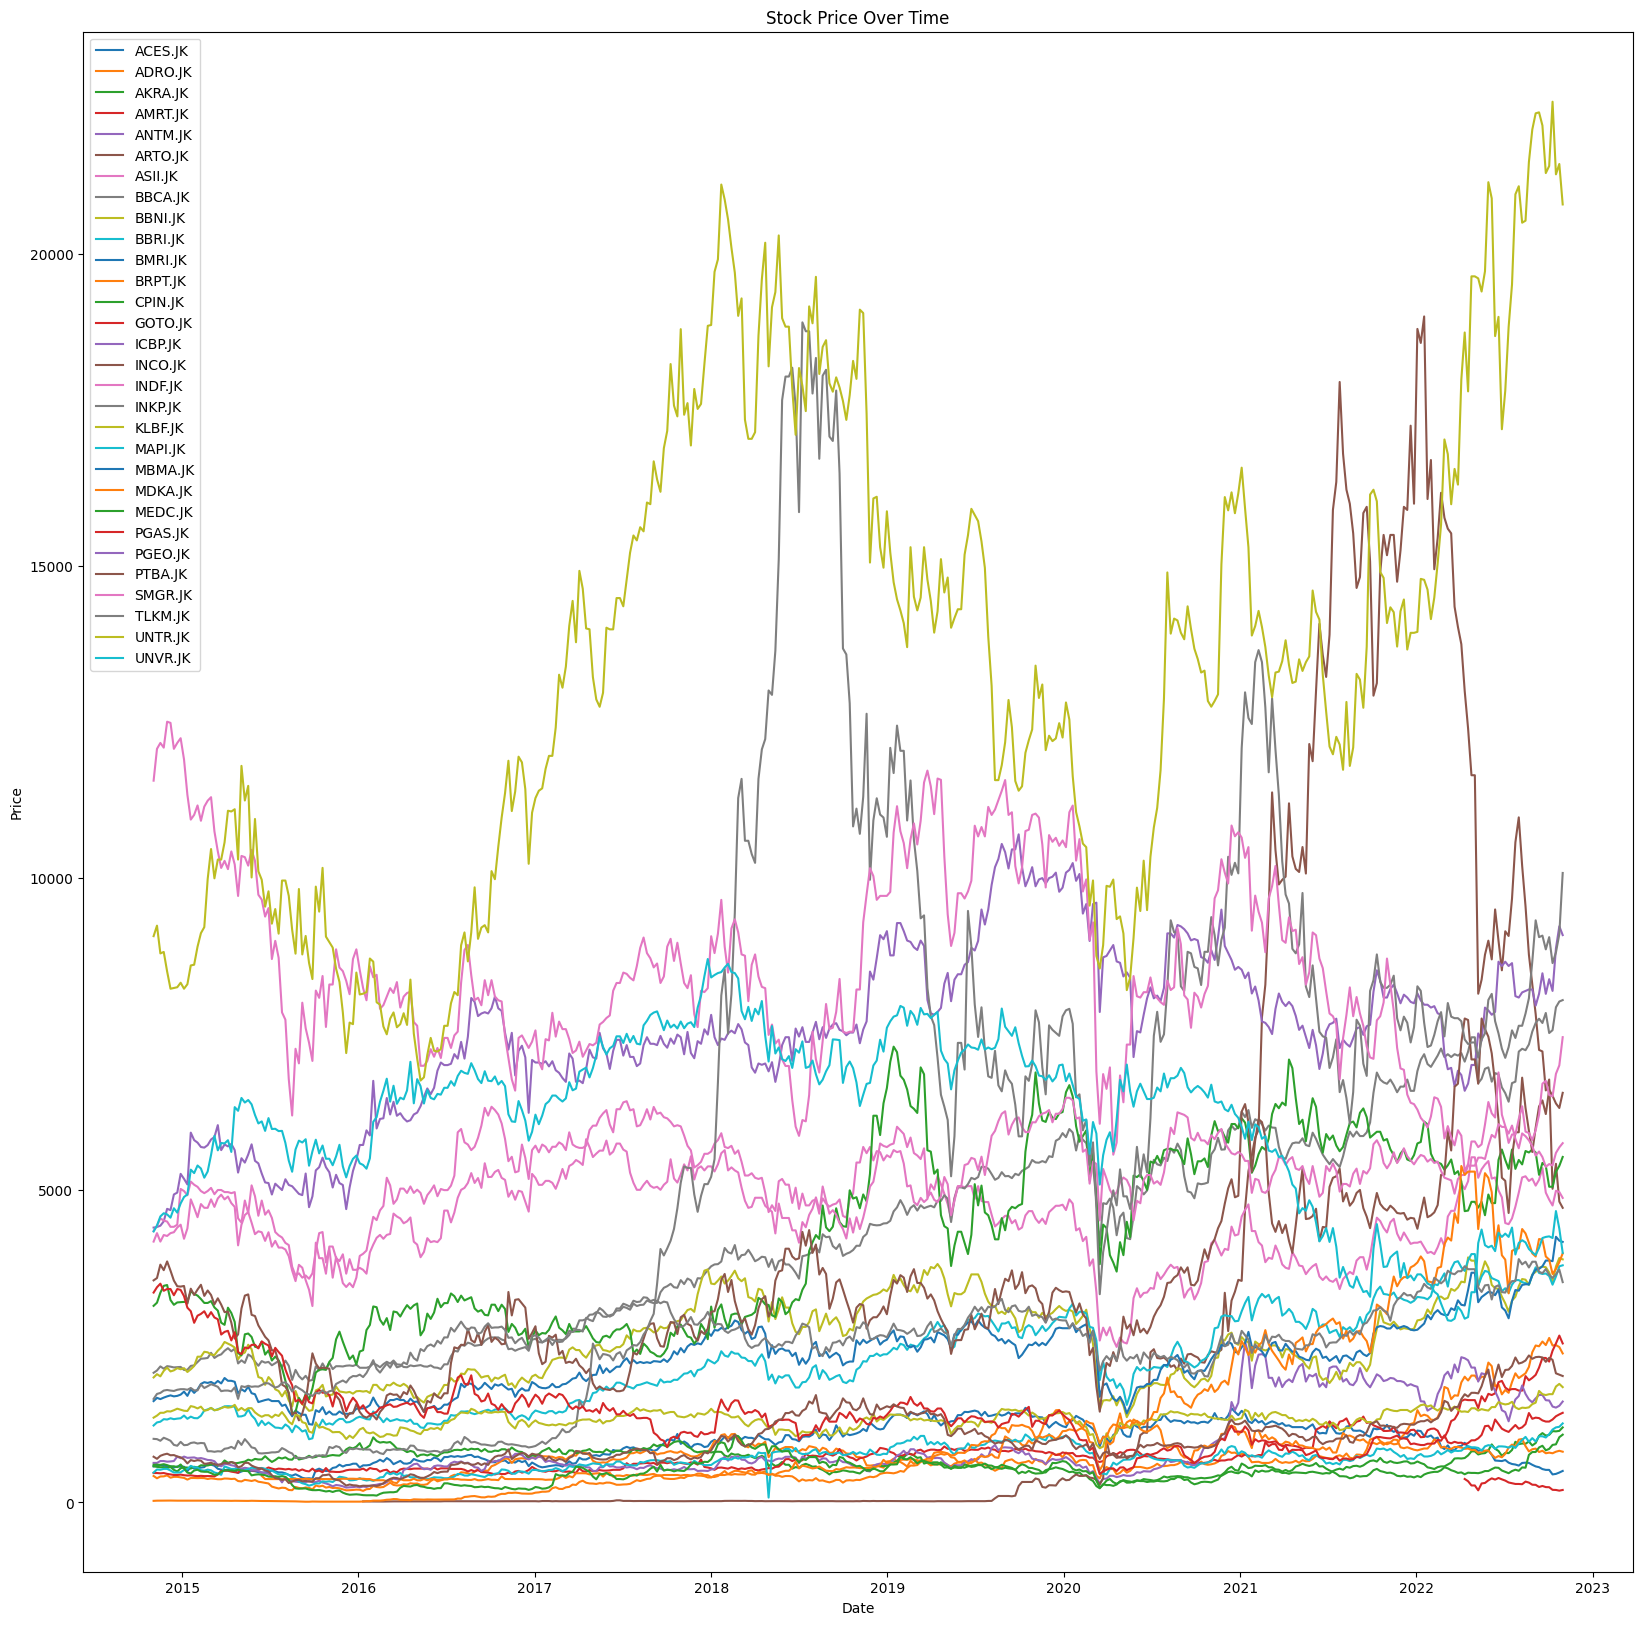

In [ ]:
plt.figure(figsize = (20,20))
plt.plot(data)
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Price Over Time")
plt.legend(data.columns)
plt.show()

# Pra Pemrosesan Data

## Pembersihan Data

In [ ]:
# Mengatur index menjadi format tanggal
data.index = data.index.date
# Simpan daftar original ticker sebelum memproses data
original_tickers = data.columns.tolist()

# Tangani data yang hilang
print("Jumlah kolom sebelum penanganan data kosong:", len(data.columns))
data_clean = data.dropna(axis=1, thresh=len(data))
print("Jumlah kolom setelah penanganan data kosong:", len(data_clean.columns))

# Identifikasi ticker yang di-drop
remaining_tickers = data_clean.columns.tolist()
dropped_tickers = [ticker for ticker in original_tickers if ticker not in remaining_tickers]

# Tampilkan ticker yang di-drop
print("\nSaham yang di-drop karena data tidak lengkap:")
for ticker in dropped_tickers:
    print(f"- {ticker}")

# Lanjutkan dengan data yang sudah dibersihkan
data = data_clean
# Menyimpan data menjadi file CSV
csv_file_path = 'stock_data_adj_close.csv'
data.to_csv(csv_file_path)

# Menampilkan beberapa data awal
print("Data Saham (Adj Close):")
data = data.dropna(axis=1, thresh=len(data))
data = data.round(0).astype(int)
data.head()

Jumlah kolom sebelum penanganan data kosong: 30
Jumlah kolom setelah penanganan data kosong: 25

Saham yang di-drop karena data tidak lengkap:
- ARTO.JK
- GOTO.JK
- MBMA.JK
- MDKA.JK
- PGEO.JK
Data Saham (Adj Close):


Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,...,INKP.JK,KLBF.JK,MAPI.JK,MEDC.JK,PGAS.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
2014-11-03,577,424,581,471,633,4179,2077,2003,1233,1624,...,1019,1358,479,603,3362,732,11563,1659,9072,4342
2014-11-10,584,387,570,471,633,4314,2114,2055,1282,1675,...,1014,1391,528,605,3448,699,12073,1738,9240,4436
2014-11-17,599,416,564,467,664,4179,2179,2020,1294,1655,...,988,1436,524,602,3505,747,12168,1754,8795,4582
2014-11-24,591,418,566,471,664,4284,2143,2108,1334,1679,...,1036,1436,538,613,3391,768,12092,1792,8819,4633
2014-12-01,580,434,551,458,654,4269,2183,2160,1328,1699,...,1014,1461,538,598,3419,781,12508,1802,8506,4615


## Return Saham

$$
R = \frac{P_t - P_{t-1}}{P_{t-1}}
$$  
di mana:
- $R$  = Return saham
- $P_t$ = Harga saham saat ini  
- $P_{t-1}$ = Harga saham sebelumnya

---

In [ ]:
#Mencari Return Stock
return_stock = data.pct_change()
return_stock

Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,...,INKP.JK,KLBF.JK,MAPI.JK,MEDC.JK,PGAS.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
2014-11-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-11-10,0.012132,-0.087264,-0.018933,0.000000,0.000000,0.032304,0.017814,0.025961,0.039740,0.031404,...,-0.004907,0.024300,0.102296,0.003317,0.025580,-0.045082,0.044106,0.047619,0.018519,0.021649
2014-11-17,0.025685,0.074935,-0.010526,-0.008493,0.048973,-0.031293,0.030747,-0.017032,0.009360,-0.011940,...,-0.025641,0.032351,-0.007576,-0.004959,0.016531,0.068670,0.007869,0.009206,-0.048160,0.032913
2014-11-24,-0.013356,0.004808,0.003546,0.008565,0.000000,0.025126,-0.016521,0.043564,0.030912,0.014502,...,0.048583,0.000000,0.026718,0.018272,-0.032525,0.028112,-0.006246,0.021665,0.002729,0.011131
2014-12-01,-0.018613,0.038278,-0.026502,-0.027601,-0.015060,-0.003501,0.018665,0.024668,-0.004498,0.011912,...,-0.021236,0.017409,0.000000,-0.024470,0.008257,0.016927,0.034403,0.005580,-0.035492,-0.003885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-03,0.000000,0.045617,0.011204,-0.025054,-0.003053,-0.022567,-0.040939,-0.022293,-0.010905,0.000000,...,0.022007,0.008721,0.051923,0.027545,0.000000,0.028863,-0.033462,-0.024606,0.005306,0.002116
2022-10-10,-0.139847,-0.045903,0.055402,0.077093,-0.059400,-0.019377,0.006117,-0.039902,-0.038313,-0.002838,...,-0.045936,0.000000,0.067642,0.074592,0.025463,-0.013811,-0.003523,-0.013984,0.048108,-0.006334
2022-10-17,0.020045,0.002386,-0.003500,0.047717,-0.011068,0.049611,0.048506,0.068420,0.037260,0.101164,...,0.019907,0.070317,0.029110,0.009761,0.039127,-0.094530,0.055650,0.016407,-0.051872,0.101983
2022-10-24,0.045852,-0.012693,0.006146,0.049470,0.019750,-0.003805,0.011597,0.035988,0.045316,-0.014568,...,0.033250,0.022617,0.008319,0.122449,0.020999,-0.010633,0.019659,0.020793,0.007849,-0.060411


## Expected Return Mingguan

Rumus:

$$
E(R) = \frac{1}{n} \sum_{t=1}^{n} R_t
$$

di mana:

<div style="margin-left: 30px; display: flex; flex-direction: column;">
  <p>- \( E(R) \) &nbsp;: Expected return saham</p>
  <p>- \( n \) &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;: Jumlah periode </p>
  <p>- \( R_t \) &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;: Return pada periode ke-\( t \)</p>
</div>


In [ ]:
#Expected Return Mingguan
expected_returns = return_stock.mean()
ExpectedReturns = expected_returns
expected_returns

,0
Ticker,
ACES.JK,0.001073
ADRO.JK,0.006462
AKRA.JK,0.003138
AMRT.JK,0.005210
ANTM.JK,0.004815
ASII.JK,0.001338
BBCA.JK,0.003720
BBNI.JK,0.002735
BBRI.JK,0.003625


In [ ]:
#Expected Return Tahunan
expected_annual_returns = expected_returns * 52  # karena ada 52 minggu dalam setahun
expected_annual_returns

,0
Ticker,
ACES.JK,0.055810
ADRO.JK,0.336017
AKRA.JK,0.163173
AMRT.JK,0.270915
ANTM.JK,0.250405
ASII.JK,0.069567
BBCA.JK,0.193429
BBNI.JK,0.142223
BBRI.JK,0.188492


## Risiko Saham

Rumus:

$$
\sigma = \sqrt{\frac{1}{n} \sum_{t=1}^{n} (R_t - \bar{R})^2}
$$

di mana:
- $σ$ = **Standar deviasi** (risiko saham)
- $R_t$ = **Return** pada periode \( t \)
- $\bar{R}$ = **Rata-rata return** saham
- $n$ = **Jumlah periode** yang digunakan dalam perhitungan


In [ ]:
return_stock.dropna()

Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,...,INKP.JK,KLBF.JK,MAPI.JK,MEDC.JK,PGAS.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
2014-11-10,0.012132,-0.087264,-0.018933,0.000000,0.000000,0.032304,0.017814,0.025961,0.039740,0.031404,...,-0.004907,0.024300,0.102296,0.003317,0.025580,-0.045082,0.044106,0.047619,0.018519,0.021649
2014-11-17,0.025685,0.074935,-0.010526,-0.008493,0.048973,-0.031293,0.030747,-0.017032,0.009360,-0.011940,...,-0.025641,0.032351,-0.007576,-0.004959,0.016531,0.068670,0.007869,0.009206,-0.048160,0.032913
2014-11-24,-0.013356,0.004808,0.003546,0.008565,0.000000,0.025126,-0.016521,0.043564,0.030912,0.014502,...,0.048583,0.000000,0.026718,0.018272,-0.032525,0.028112,-0.006246,0.021665,0.002729,0.011131
2014-12-01,-0.018613,0.038278,-0.026502,-0.027601,-0.015060,-0.003501,0.018665,0.024668,-0.004498,0.011912,...,-0.021236,0.017409,0.000000,-0.024470,0.008257,0.016927,0.034403,0.005580,-0.035492,-0.003885
2014-12-08,-0.005172,-0.085253,0.030853,-0.019651,0.004587,0.010541,-0.003665,-0.028241,0.015813,0.009417,...,-0.025641,-0.002738,-0.048327,-0.033445,0.000000,-0.032010,-0.001519,-0.005549,-0.032448,-0.011484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-10-03,0.000000,0.045617,0.011204,-0.025054,-0.003053,-0.022567,-0.040939,-0.022293,-0.010905,0.000000,...,0.022007,0.008721,0.051923,0.027545,0.000000,0.028863,-0.033462,-0.024606,0.005306,0.002116
2022-10-10,-0.139847,-0.045903,0.055402,0.077093,-0.059400,-0.019377,0.006117,-0.039902,-0.038313,-0.002838,...,-0.045936,0.000000,0.067642,0.074592,0.025463,-0.013811,-0.003523,-0.013984,0.048108,-0.006334
2022-10-17,0.020045,0.002386,-0.003500,0.047717,-0.011068,0.049611,0.048506,0.068420,0.037260,0.101164,...,0.019907,0.070317,0.029110,0.009761,0.039127,-0.094530,0.055650,0.016407,-0.051872,0.101983
2022-10-24,0.045852,-0.012693,0.006146,0.049470,0.019750,-0.003805,0.011597,0.035988,0.045316,-0.014568,...,0.033250,0.022617,0.008319,0.122449,0.020999,-0.010633,0.019659,0.020793,0.007849,-0.060411


In [ ]:
varians_populasi = ((return_stock['ACES.JK'].dropna() - expected_returns['ACES.JK']) ** 2).sum() / len(return_stock)
varians_populasi

std_manual = varians_populasi ** 0.5
std_manual

np.float64(0.05336856548903377)

In [ ]:
variansi_stock = return_stock.var()
variansi_stock

,0
Ticker,
ACES.JK,0.002862
ADRO.JK,0.004717
AKRA.JK,0.002812
AMRT.JK,0.002422
ANTM.JK,0.005361
ASII.JK,0.001972
BBCA.JK,0.000935
BBNI.JK,0.002248
BBRI.JK,0.001833


In [ ]:
akar_varians = variansi_stock ** 0.5
akar_varians

,0
Ticker,
ACES.JK,0.053497
ADRO.JK,0.068683
AKRA.JK,0.053030
AMRT.JK,0.049214
ANTM.JK,0.073218
ASII.JK,0.044404
BBCA.JK,0.030585
BBNI.JK,0.047413
BBRI.JK,0.042813


In [ ]:
#Resiko
risk_stock = return_stock.dropna().std()
risk_stock

,0
Ticker,
ACES.JK,0.053497
ADRO.JK,0.068683
AKRA.JK,0.053030
AMRT.JK,0.049214
ANTM.JK,0.073218
ASII.JK,0.044404
BBCA.JK,0.030585
BBNI.JK,0.047413
BBRI.JK,0.042813


## Covarian

Rumus :

$$
Cov(X, Y) = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})
$$

di mana:
- $X$ dan $Y$ = dua set data (misalnya, return saham dari dua saham berbeda)
- $ X_i $ dan $ Y_i $ = elemen-elemen individual dari masing-masing dataset pada indeks $i$
- $\bar{X}$ dan $ \bar{Y}$ = rata-rata dari data $ X $ dan $Y $
- $n $ = jumlah data dalam set (jumlah periode)


In [ ]:
cov_manual = sum((return_stock["ACES.JK"].dropna() - expected_returns['ACES.JK']) * (return_stock["ADRO.JK"].dropna() - expected_returns['ADRO.JK'])) / (521 - 1)
cov_pandas = return_stock.cov().iloc[0, 1]
print(f"Kovarian Manual: {cov_manual}")
print(f"Kovarian dari Pandas .cov(): {cov_pandas}")


Kovarian Manual: 0.000722981158290922
Kovarian dari Pandas .cov(): 0.0009037264478636539


In [ ]:
#Covarian
cov_stock = return_stock.cov()
cov_stock

Ticker,ACES.JK,ADRO.JK,AKRA.JK,AMRT.JK,ANTM.JK,ASII.JK,BBCA.JK,BBNI.JK,BBRI.JK,BMRI.JK,...,INKP.JK,KLBF.JK,MAPI.JK,MEDC.JK,PGAS.JK,PTBA.JK,SMGR.JK,TLKM.JK,UNTR.JK,UNVR.JK
Ticker,,,,,,,,,,,,,,,,,,,,,
ACES.JK,0.002862,0.000904,0.000390,0.000020,0.000693,0.000803,0.000495,0.000870,0.000830,0.000672,...,0.000808,0.000470,-0.000144,0.000483,0.000519,0.000486,0.000710,0.000339,0.000307,0.000353
ADRO.JK,0.000904,0.004717,0.001117,0.000063,0.001541,0.000845,0.000827,0.001246,0.001116,0.001087,...,0.001121,0.000735,0.002968,0.001686,0.001402,0.002413,0.001026,0.000479,0.001730,0.000356
AKRA.JK,0.000390,0.001117,0.002812,0.000065,0.001106,0.000598,0.000572,0.000824,0.000710,0.000733,...,0.000814,0.000572,0.002152,0.000979,0.000884,0.000484,0.000706,0.000487,0.000491,0.000349
AMRT.JK,0.000020,0.000063,0.000065,0.002422,0.000166,0.000049,0.000041,0.000087,-0.000044,0.000030,...,0.000161,0.000066,-0.000222,0.000271,0.000230,0.000121,0.000114,0.000195,-0.000058,-0.000035
ANTM.JK,0.000693,0.001541,0.001106,0.000166,0.005361,0.000940,0.000678,0.001097,0.000929,0.000811,...,0.001592,0.000490,0.000265,0.002111,0.002021,0.001493,0.000921,0.000668,0.000722,0.000310
ASII.JK,0.000803,0.000845,0.000598,0.000049,0.000940,0.001972,0.000763,0.001089,0.001093,0.001079,...,0.001004,0.000680,0.000355,0.000770,0.001081,0.000710,0.001100,0.000550,0.000750,0.000524
BBCA.JK,0.000495,0.000827,0.000572,0.000041,0.000678,0.000763,0.000935,0.000917,0.000851,0.000835,...,0.000748,0.000479,0.001295,0.000754,0.000791,0.000569,0.000699,0.000449,0.000396,0.000359
BBNI.JK,0.000870,0.001246,0.000824,0.000087,0.001097,0.001089,0.000917,0.002248,0.001515,0.001460,...,0.001030,0.000754,0.003505,0.001107,0.001279,0.000877,0.001172,0.000718,0.000608,0.000559
BBRI.JK,0.000830,0.001116,0.000710,-0.000044,0.000929,0.001093,0.000851,0.001515,0.001833,0.001309,...,0.000931,0.000641,0.001936,0.000779,0.001051,0.000806,0.000987,0.000586,0.000668,0.000430


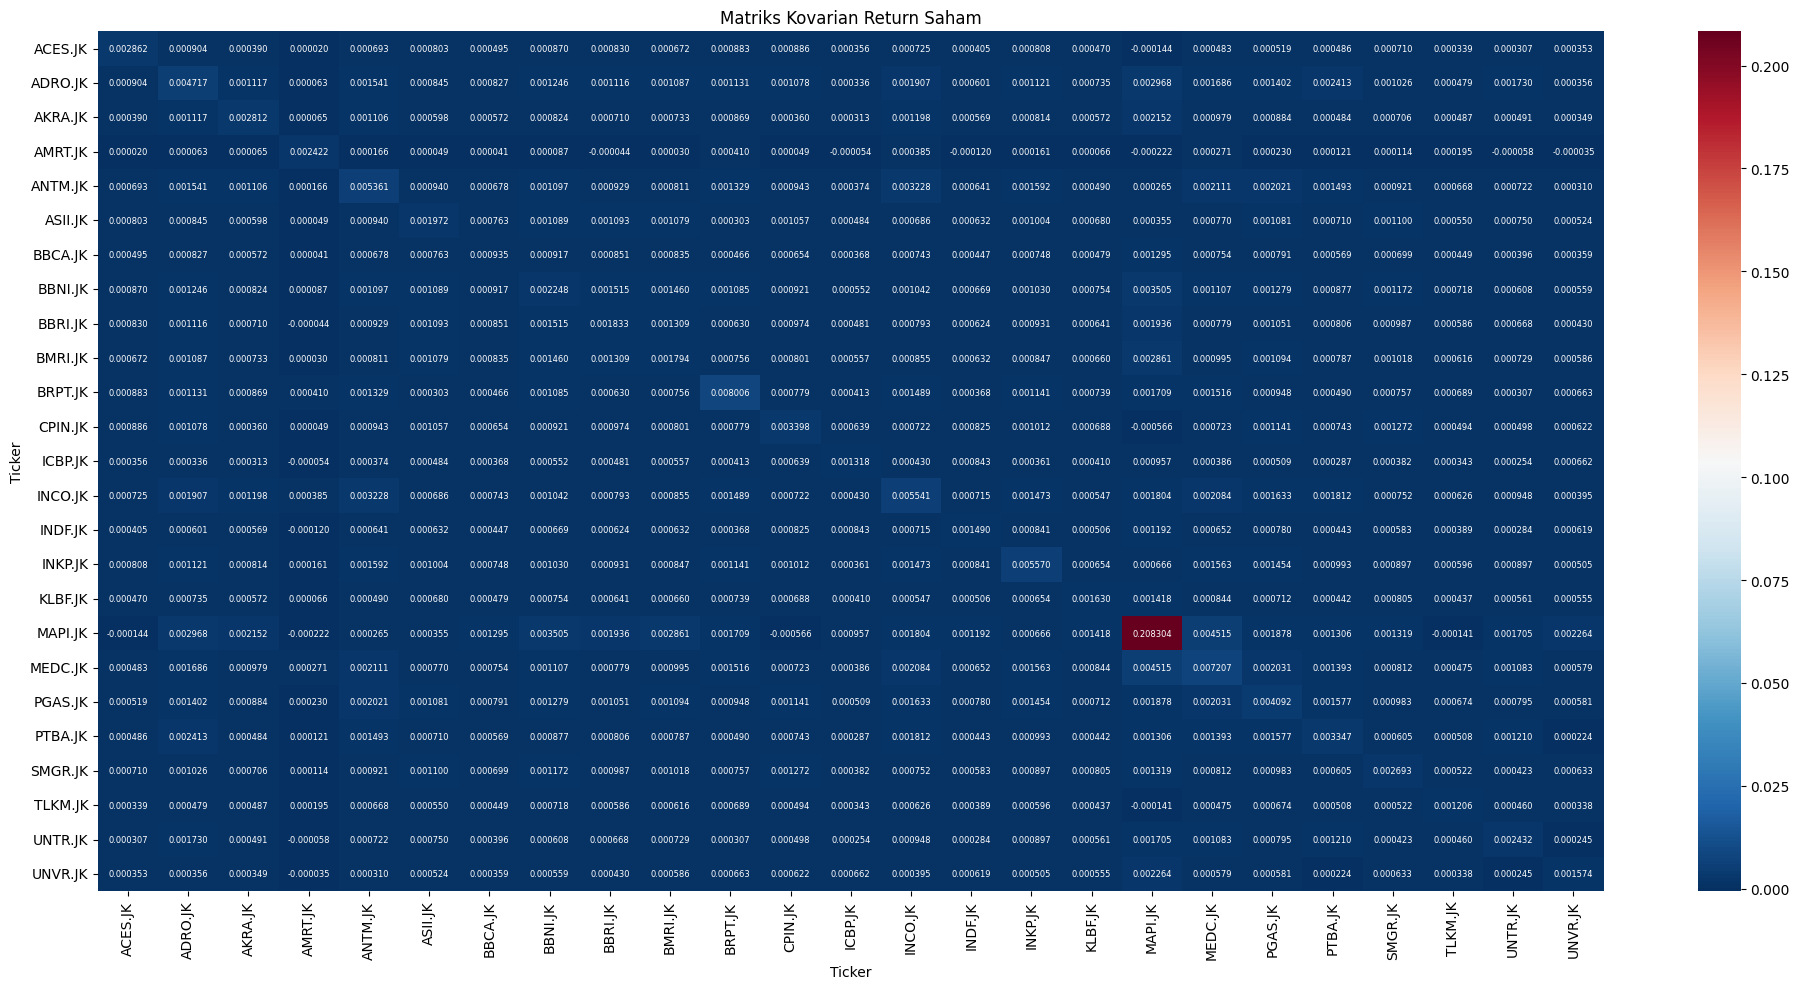

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
sns.heatmap(cov_stock,
            annot=True,  # Menampilkan nilai
            fmt=".6f",   # Format nilai dengan 6 desimal
            cmap="RdBu_r",annot_kws={"size": 6}
            )  # Colormap merah-putih-biru

plt.title("Matriks Kovarian Return Saham")
plt.tight_layout()
plt.show()

##PORTOFOLIO

### Return Portofolio

Rumus Return Portofolio:

$$
R_p = \sum_{i=1}^{n} w_i \cdot R_i
$$

di mana:
- $R_p $ = **Return portofolio**
- $w_i $ = **Bobot** atau proporsi investasi dalam aset $i$
- $R_i $ = **Return** aset $i$
- $ n $  = **Jumlah aset** dalam portofolio


In [ ]:
weights = np.array([1/25] * 25)  # bobot sama rata
weights
portfolio_weekly_return = return_stock.dropna().dot(weights)
portfolio_weekly_return.name = "Portofolio Return"
portfolio_weekly_return = portfolio_weekly_return.to_frame()
portfolio_weekly_return

,Portofolio Return
2014-11-10,0.016636
2014-11-17,0.014744
2014-11-24,0.010867
2014-12-01,0.003090
2014-12-08,-0.015775
...,...
2022-10-03,0.002834
2022-10-10,-0.005138
2022-10-17,0.029476
2022-10-24,0.017955


###Expected Return Portofolio

In [ ]:
expected_return_portfolio = portfolio_weekly_return.mean().values[0]
print("Expected Return Portofolio (Mingguan):", round(expected_return_portfolio, 4))
expected_annual_return = portfolio_weekly_return.mean().values[0] * 52
print("Expected Return Portoflio (Tahunan):", round(expected_annual_return, 4))

Expected Return Portofolio (Mingguan): 0.0043
Expected Return Portoflio (Tahunan): 0.2232


### Resiko Portofolio



In [ ]:
portfolio_variance = np.sqrt(np.dot(weights.T, np.dot(cov_stock, weights)))
portfolio_std_dev = np.sqrt(portfolio_variance)
print("Portfolio Variance:", round(portfolio_variance, 4))
print("Portfolio Standard Deviation:", round(portfolio_std_dev, 4))

Portfolio Variance: 0.035
Portfolio Standard Deviation: 0.1871


In [ ]:
risk_portfolio = portfolio_weekly_return.std().values[0]
print("Risk Portofolio (Mingguan):", round(risk_portfolio, 4))
risk_annual = portfolio_weekly_return.std().values[0] * np.sqrt(52)
print("Risk Portfolio (Tahunan):", round(risk_annual, 4))


Risk Portofolio (Mingguan): 0.035
Risk Portfolio (Tahunan): 0.2525


In [ ]:
risk_free_rate = 0.0665
sharpe_ratio = (expected_annual_return - risk_free_rate) / risk_annual
print("Sharpe Ratio:", round(sharpe_ratio, 4))


Sharpe Ratio: 0.6204


#Testing Kode

**Min ($X_1 ^2 + X_2 ^2 + ... +X_n ^2$)**

**Dengan Constraint** $X_1 + X_2 +...+ X_n \geq 1 $

In [ ]:
class ImprovedPSOFixedW:
    def __init__(self, num_particles=None, max_iter=1000, dim=5, w=0.7):
        if num_particles is None:
            num_particles = max(30, dim * 15)

        self.num_particles = num_particles
        self.max_iter = max_iter
        self.dim = dim
        self.w = w  # Inertia weight tetap

        self.c1 = 2.0
        self.c2 = 2.0

        self.positions = np.random.uniform(0, 1, (num_particles, dim))
        self.velocities = np.random.uniform(-0.1, 0.1, (num_particles, dim))

        for i in range(num_particles):
            s = np.sum(self.positions[i])
            self.positions[i] = self.positions[i] / s if s > 0 else np.ones(dim)/dim

        self.personal_best_positions = self.positions.copy()
        self.personal_best_scores = np.array([self.fitness(p) for p in self.positions])

        best_idx = np.argmin(self.personal_best_scores)
        self.global_best_position = self.personal_best_positions[best_idx].copy()
        self.global_best_score = self.personal_best_scores[best_idx]

        self.history = []
        self.best_position_history = []

    def fitness(self, x):
        objective = np.sum(x**2)
        const = np.sum(x)
        penalty = 0
        if const < 1:
            penalty += 1 - const
        return objective + penalty

    def repair_solution(self, x):
        x = np.maximum(x, 0)
        s = np.sum(x)
        x = x / s if s > 0 else np.ones(self.dim)/self.dim
        x = np.clip(x, 0, 1)
        s = np.sum(x)
        return x / s if s > 0 else np.ones(self.dim)/self.dim

    def optimize(self, verbose=True):
        if verbose:
            print(f"Running PSO with fixed inertia weight w = {self.w}")

        for iter in range(self.max_iter):
            for i in range(self.num_particles):
                self.positions[i] = self.repair_solution(self.positions[i])
                fit = self.fitness(self.positions[i])

                if fit < self.personal_best_scores[i]:
                    self.personal_best_scores[i] = fit
                    self.personal_best_positions[i] = self.positions[i].copy()

                    if fit < self.global_best_score:
                        self.global_best_score = fit
                        self.global_best_position = self.positions[i].copy()

            for i in range(self.num_particles):
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)

                cognitive = self.c1 * r1 * (self.personal_best_positions[i] - self.positions[i])
                social = self.c2 * r2 * (self.global_best_position - self.positions[i])
                self.velocities[i] = self.w * self.velocities[i] + cognitive + social

                v_max = 0.2
                self.velocities[i] = np.clip(self.velocities[i], -v_max, v_max)
                self.positions[i] += self.velocities[i]

            self.history.append(self.global_best_score)
            self.best_position_history.append(self.global_best_position.copy())

            if verbose and (iter + 1) % max(100, self.max_iter // 10) == 0:
                print(f"Iter {iter+1:4d} | Best Fitness: {self.global_best_score:.8f} | ∑x = {np.sum(self.global_best_position):.6f}")

        return self.global_best_position, self.global_best_score

    def plot_convergence(self):
        plt.figure(figsize=(10, 5))
        plt.semilogy(self.history)
        plt.title("Convergence Plot (Log Scale)")
        plt.xlabel("Iterasi")
        plt.ylabel("Fitness Terbaik")
        plt.grid(True)
        plt.show()

    def plot_dimension_convergence(self):
        position_array = np.array(self.best_position_history)
        plt.figure(figsize=(12, 6))
        for d in range(min(self.dim, 10)):  # Only plot first 10 dimensions
            plt.plot(position_array[:, d], label=f'x{d+1}', alpha=0.8)

        # Add horizontal line at 1/dim (optimal value)
        plt.axhline(y=1/self.dim, color='red', linestyle='--', alpha=0.7,
                   label=f'Optimal (1/{self.dim} = {1/self.dim:.3f})')

        plt.title('Konvergensi per Dimensi')
        plt.xlabel('Iterasi')
        plt.ylabel('Nilai Posisi')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_best_position_bar(self):
        plt.figure(figsize=(max(8, self.dim), 6))
        dim_labels = [f'x{i+1}' for i in range(self.dim)]
        bars = plt.bar(dim_labels, self.global_best_position, alpha=0.7)

        # Add horizontal line at optimal value
        optimal_val = 1/self.dim
        plt.axhline(y=optimal_val, color='red', linestyle='--', alpha=0.7,
                   label=f'Optimal = {optimal_val:.3f}')

        plt.title(f'Posisi Terbaik per Variabel (dim={self.dim})')
        plt.xlabel('Variabel')
        plt.ylabel('Nilai Posisi')
        plt.legend()

        # Add value labels on bars if not too many
        if self.dim <= 20:
            for bar, val in zip(bars, self.global_best_position):
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                        f'{val:.3f}', ha='center', va='bottom', fontsize=8)

        plt.xticks(rotation=45 if self.dim > 10 else 0)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

    def print_analysis(self):
        """Print detailed analysis of results"""
        print("\n" + "="*50)
        print("ANALISIS HASIL PSO")
        print("="*50)
        print(f"Dimensi problem: {self.dim}")
        print(f"Jumlah partikel: {self.num_particles}")
        print(f"Maksimum iterasi: {self.max_iter}")
        print("-"*50)
        print(f"Fitness terbaik: {self.global_best_score:.8f}")
        print(f"Sum constraint: {np.sum(self.global_best_position):.6f}")
        print(f"Target sum: 1.000000")
        print(f"Error sum: {abs(np.sum(self.global_best_position) - 1.0):.6f}")
        print("-"*50)
        print("Posisi terbaik per variabel:")
        optimal_val = 1/self.dim
        for i, val in enumerate(self.global_best_position):
            error = abs(val - optimal_val)
            print(f"  x{i+1:2d} = {val:.6f} (optimal: {optimal_val:.6f}, error: {error:.6f})")
        print("-"*50)
        max_error = max(abs(val - optimal_val) for val in self.global_best_position)
        print(f"Maximum error dari nilai optimal: {max_error:.6f}")
        print(f"Standard deviation: {np.std(self.global_best_position):.6f}")


def run_multiple_experiments(dim=10, num_runs=50, max_iter=2000, w=0.7, verbose=True):
    """
    Menjalankan PSO sebanyak num_runs kali dan menganalisis statistik hasilnya
    """
    print(f"\n{'='*60}")
    print(f"MENJALANKAN {num_runs} EKSPERIMEN PSO")
    print(f"Dimensi: {dim}, Max Iterasi: {max_iter}, Inertia Weight: {w}")
    print(f"{'='*60}")

    results = []
    best_positions = []
    computation_times = []

    for run in range(num_runs):
        if verbose:
            print(f"\nRun {run+1}/{num_runs}")

        start_time = time.time()

        # Buat instance PSO baru untuk setiap run
        pso = ImprovedPSOFixedW(max_iter=max_iter, dim=dim, w=w)
        best_pos, best_score = pso.optimize(verbose=False)

        end_time = time.time()

        results.append(best_score)
        best_positions.append(best_pos)
        computation_times.append(end_time - start_time)

        if verbose:
            print(f"  Fitness: {best_score:.8f}, Time: {end_time - start_time:.2f}s")

    # Konversi ke numpy arrays untuk analisis
    results = np.array(results)
    best_positions = np.array(best_positions)
    computation_times = np.array(computation_times)

    # Hitung statistik
    mean_fitness = np.mean(results)
    min_fitness = np.min(results)
    max_fitness = np.max(results)
    std_fitness = np.std(results)
    variance_fitness = np.var(results)
    median_fitness = np.median(results)

    # Temukan run terbaik dan terburuk
    best_run_idx = np.argmin(results)
    worst_run_idx = np.argmax(results)

    # Print hasil analisis statistik
    print(f"\n{'='*60}")
    print("ANALISIS STATISTIK HASIL")
    print(f"{'='*60}")
    print(f"Jumlah eksperimen: {num_runs}")
    print(f"Dimensi problem: {dim}")
    print(f"{'─'*60}")
    print("STATISTIK FITNESS:")
    print(f"  Rata-rata (Mean)    : {mean_fitness:.8f}")
    print(f"  Nilai terendah (Min): {min_fitness:.8f}")
    print(f"  Nilai tertinggi (Max): {max_fitness:.8f}")
    print(f"  Median              : {median_fitness:.8f}")
    print(f"  Standard Deviasi    : {std_fitness:.8f}")
    print(f"  Variansi            : {variance_fitness:.8f}")
    print(f"{'─'*60}")
    print("STATISTIK WAKTU KOMPUTASI:")
    print(f"  Rata-rata waktu     : {np.mean(computation_times):.2f} detik")
    print(f"  Waktu tercepat      : {np.min(computation_times):.2f} detik")
    print(f"  Waktu terlama       : {np.max(computation_times):.2f} detik")
    print(f"  Total waktu         : {np.sum(computation_times):.2f} detik")

    # Plot

    return {
        'results': results,
        'best_positions': best_positions,
        'statistics': {
            'mean': mean_fitness,
            'min': min_fitness,
            'max': max_fitness,
            'std': std_fitness,
            'variance': variance_fitness,
            'median': median_fitness
        },
        'computation_times': computation_times,
        'best_run_idx': best_run_idx,
        'worst_run_idx': worst_run_idx
    }


In [ ]:
if __name__ == "__main__":
    # Jalankan eksperimen
    experiment_results = run_multiple_experiments(
        dim=25,
        num_runs=50,
        max_iter=1000,
        w=0.7,
        verbose=True
    )

    print(f"\n{'='*60}")
    print("EKSPERIMEN SELESAI")
    print(f"{'='*60}")


MENJALANKAN 50 EKSPERIMEN PSO
Dimensi: 25, Max Iterasi: 1000, Inertia Weight: 0.7

Run 1/50
  Fitness: 0.04000420, Time: 17.54s

Run 2/50
  Fitness: 0.04000303, Time: 16.57s

Run 3/50
  Fitness: 0.04000398, Time: 17.84s

Run 4/50
  Fitness: 0.04000279, Time: 16.64s

Run 5/50
  Fitness: 0.04000494, Time: 17.21s

Run 6/50
  Fitness: 0.04000028, Time: 17.81s

Run 7/50
  Fitness: 0.04000674, Time: 16.42s

Run 8/50
  Fitness: 0.04000338, Time: 16.72s

Run 9/50
  Fitness: 0.04000237, Time: 20.72s

Run 10/50
  Fitness: 0.04000209, Time: 16.80s

Run 11/50
  Fitness: 0.04000265, Time: 16.97s

Run 12/50
  Fitness: 0.04000437, Time: 17.88s

Run 13/50
  Fitness: 0.04000860, Time: 17.03s

Run 14/50
  Fitness: 0.04000715, Time: 17.66s

Run 15/50
  Fitness: 0.04000661, Time: 17.36s

Run 16/50
  Fitness: 0.04000374, Time: 16.53s

Run 17/50
  Fitness: 0.04000201, Time: 17.06s

Run 18/50
  Fitness: 0.04000279, Time: 17.39s

Run 19/50
  Fitness: 0.04000548, Time: 16.63s

Run 20/50
  Fitness: 0.04000210,

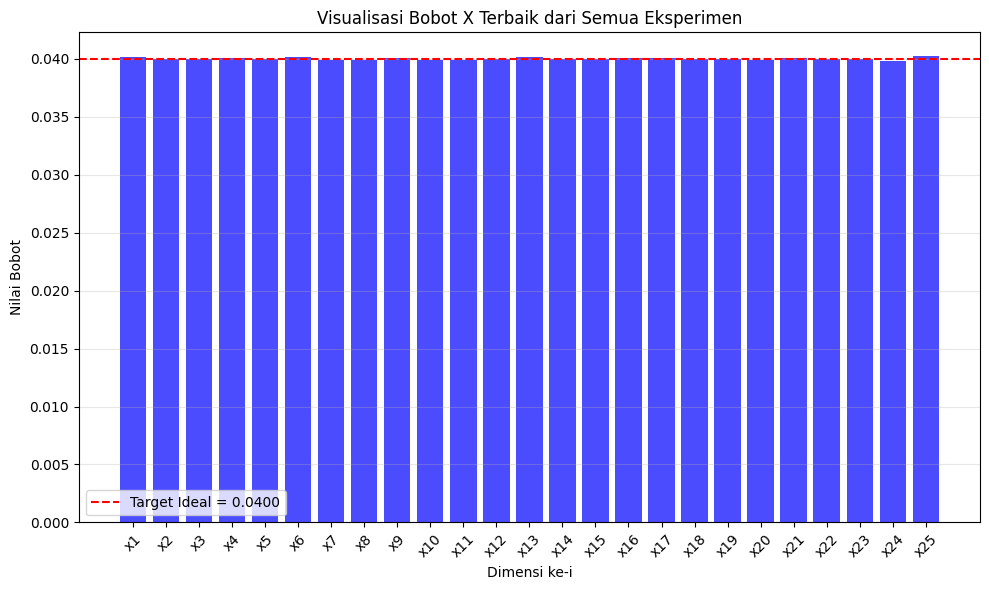

In [ ]:
# Ambil data untuk plotting
best_positions = experiment_results["best_positions"]
best_run_idx = experiment_results["best_run_idx"]
dim =25

best_x = best_positions[best_run_idx]

plt.figure(figsize=(10, 6))
plt.bar([f'x{i+1}' for i in range(dim)], best_x, alpha=0.7, color='blue')
plt.axhline(y=1/dim, color='red', linestyle='--', label=f'Target Ideal = {1/dim:.4f}')
plt.title('Visualisasi Bobot X Terbaik dari Semua Eksperimen')
plt.xlabel('Dimensi ke-i')
plt.ylabel('Nilai Bobot')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
if __name__ == "__main__":


    # Jalankan eksperimen
    experiment_results_05 = run_multiple_experiments(
        dim=25,
        num_runs=50,
        max_iter=1000,
        w=0.5,
        verbose=True
    )

    print(f"\n{'='*60}")
    print("EKSPERIMEN SELESAI")
    print(f"{'='*60}")


MENJALANKAN 50 EKSPERIMEN PSO
Dimensi: 25, Max Iterasi: 1000, Inertia Weight: 0.5

Run 1/50
  Fitness: 0.04000000, Time: 17.37s

Run 2/50
  Fitness: 0.04000000, Time: 17.07s

Run 3/50
  Fitness: 0.04000000, Time: 16.65s

Run 4/50
  Fitness: 0.04000000, Time: 17.30s

Run 5/50
  Fitness: 0.04000000, Time: 17.26s

Run 6/50
  Fitness: 0.04000000, Time: 16.56s

Run 7/50
  Fitness: 0.04000000, Time: 17.05s

Run 8/50
  Fitness: 0.04000000, Time: 17.47s

Run 9/50
  Fitness: 0.04000000, Time: 16.70s

Run 10/50
  Fitness: 0.04000000, Time: 16.72s

Run 11/50
  Fitness: 0.04000000, Time: 17.81s

Run 12/50
  Fitness: 0.04000000, Time: 16.52s

Run 13/50
  Fitness: 0.04000000, Time: 16.80s

Run 14/50
  Fitness: 0.04000000, Time: 17.96s

Run 15/50
  Fitness: 0.04000000, Time: 16.86s

Run 16/50
  Fitness: 0.04000000, Time: 17.08s

Run 17/50
  Fitness: 0.04000000, Time: 17.90s

Run 18/50
  Fitness: 0.04000000, Time: 16.76s

Run 19/50
  Fitness: 0.04000000, Time: 17.91s

Run 20/50
  Fitness: 0.04000000,

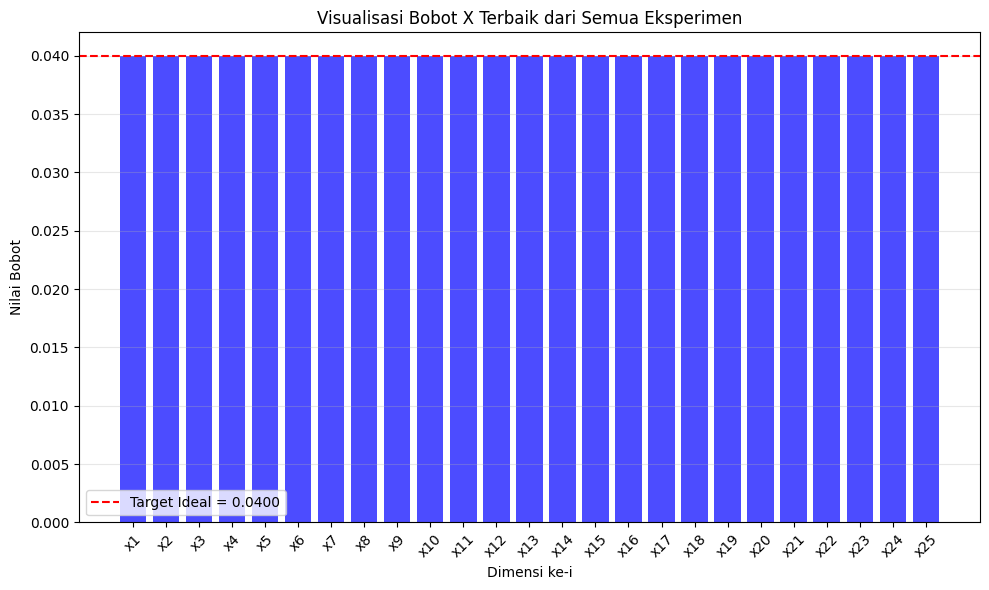

In [ ]:
# Ambil data untuk plotting
best_positions = experiment_results_05["best_positions"]
best_run_idx = experiment_results_05["best_run_idx"]
dim =25

best_x = best_positions[best_run_idx]

plt.figure(figsize=(10, 6))
plt.bar([f'x{i+1}' for i in range(dim)], best_x, alpha=0.7, color='blue')
plt.axhline(y=1/dim, color='red', linestyle='--', label=f'Target Ideal = {1/dim:.4f}')
plt.title('Visualisasi Bobot X Terbaik dari Semua Eksperimen')
plt.xlabel('Dimensi ke-i')
plt.ylabel('Nilai Bobot')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#Implementasi Model

Masalah Optimasi -> Meminimunkan Resiko  
$$\min_{w} \frac{1}{2} w^T V w $$
Constraint ->   
$$w^T 1 = 1$$
$$w^T 𝜇 \geq 𝜇_p^*$$
$$w^T \theta \leq θ_p^*$$

$$
v_i^{t+1} = \omega v_i^t + c_1 r_1 \left( p_{best_i}^t - x_i^t \right) + c_2 r_2 \left( g_{best} - x_i^t \right)
$$

**Keterangan:**

- $p_{best_i}^t$ = posisi terbaik pribadi partikel *i*  
- $g_{best}$ = posisi terbaik global  
- $x_i^t$ = posisi terbaik partikel *i* pada iterasi ke-*t*  
- $\omega$ = faktor inersia  
- $c$ = koefisien akselerasi  
- $r$ = bilangan acak dengan distribusi *uniform* antara 0 dan 1

##TANPA ESG

In [ ]:
class PortfolioOptimizationPSO:
    """
    Optimisasi Portofolio Tanpa Mempertimbangkan ESG
    Single Objective: Minimasi Risiko dengan return sebagai constraints
    """

    def __init__(self, mu, cov, theta=None, stock_names=None,
                 mu_p_star=0.002, theta_p_star=None,
                 max_iter=1000, num_particles=None, objective='risk'):


        self.mu = mu
        self.cov = cov
        self.theta = theta if theta is not None else None
        self.stock_names = stock_names if stock_names is not None else [f'Asset_{i+1}' for i in range(len(self.mu))]

        # Portfolio parameters
        self.mu_p_star = mu_p_star  # Target Return
        self.theta_p_star = theta_p_star  # Target nilai ESG
        self.objective = "risk"

        self.dim = len(self.mu)

        # PSO parameters
        if num_particles is None:
            num_particles = max(30, self.dim * 15)

        self.num_particles = num_particles
        self.max_iter = max_iter
        self.c1 = 2.0         # Cognitive coefficient
        self.c2 = 2.0         # Social coefficient

        # Inisialisasi partikel
        self._initialize_particles()

        self.history = []
        self.best_position_history = []
        self.return_history = []
        self.risk_history = []
        self.esg_history = [] if self.theta is not None else None

    def _initialize_particles(self):
        print(f"Initializing PSO with {self.num_particles} particles for {self.dim} assets")

        # Inisialisasi posisi partikel
        self.positions = np.random.uniform(0, 1, (self.num_particles, self.dim))
        # Inisialisasi kecepatan partikel
        self.velocities = np.random.uniform(0, 1, (self.num_particles, self.dim))

        for i in range(self.num_particles):
            self.positions[i] = self._repair_solution(self.positions[i])

        # Inisialisasi personal bests
        self.personal_best_positions = self.positions.copy()
        self.personal_best_scores = np.array([self.fitness(p) for p in self.positions])

        # Inisialisasi global best
        best_idx = np.argmin(self.personal_best_scores)
        self.global_best_position = self.personal_best_positions[best_idx].copy()
        self.global_best_score = self.personal_best_scores[best_idx]

    def _repair_solution(self, position):
        position = np.maximum(position, 0)

        sum_pos = np.sum(position)
        if sum_pos > 0:
            position = position / sum_pos
        else:
            position = np.ones(self.dim) / self.dim

        position = np.clip(position, 0, 1)

        sum_pos = np.sum(position)
        if sum_pos > 0:
            position = position / sum_pos

        return position

    def fitness(self, weights):
        weights = self._repair_solution(weights)

        port_return = np.dot(weights.T, self.mu)
        port_variance = 0.5*np.dot(weights.T, np.dot(self.cov, weights))
        port_esg = np.dot(weights.T, self.theta)

        objective = port_variance  # Minimasi Resiko


        # Penalty untuk constraints
        penalty = 0

        # Return constraint
        if port_return < self.mu_p_star:
            penalty += (self.mu_p_star - port_return)

        # ESG constraint
        if self.theta_p_star is not None:
          if port_esg > self.theta_p_star:
            penalty += (port_esg - self.theta_p_star)

        return objective + penalty

    def optimize(self):
        """Main optimization loop"""
        print(f"Starting Enhanced Portfolio PSO optimization")
        print(f"Objective: {self.objective.capitalize()}")
        print(f"Assets: {self.dim}, Particles: {self.num_particles}, Iterations: {self.max_iter}")
        print(f"Target Return: {self.mu_p_star*100:.2f}%")
        print(f"Target ESG: ≤ {self.theta_p_star}")
        print("-" * 60)

        for iteration in range(self.max_iter):
            current_w = 0.5

            # perbarui nilai fitness dan personal bests
            for i in range(self.num_particles):
                self.positions[i] = self._repair_solution(self.positions[i])

                current_fitness = self.fitness(self.positions[i])

                if current_fitness < self.personal_best_scores[i]:
                    self.personal_best_scores[i] = current_fitness
                    self.personal_best_positions[i] = self.positions[i].copy()
                    if current_fitness < self.global_best_score:
                        self.global_best_score = current_fitness
                        self.global_best_position = self.positions[i].copy()

            # Perbarui kecepatan dan posisi
            for i in range(self.num_particles):
                r1 = np.random.rand(self.dim)
                r2 = np.random.rand(self.dim)

                cognitive = self.c1 * r1 * (self.personal_best_positions[i] - self.positions[i])
                social = self.c2 * r2 * (self.global_best_position - self.positions[i])

                self.velocities[i] = current_w * self.velocities[i] + cognitive + social

                v_max = 0.2
                self.velocities[i] = np.clip(self.velocities[i], -v_max, v_max)

                self.positions[i] += self.velocities[i]

            self._update_history()

            if (iteration + 1) % max(50, self.max_iter // 20) == 0:
                self._print_progress(iteration + 1, current_w)

        self._calculate_final_metrics()
        print("\nOptimization completed!")

        return {
          "weights": self.optimal_weights,
          "expected_return": self.optimal_return,
          "volatility": self.optimal_volatility,
          "sharpe_ratio": self.optimal_sharpe,
          "esg_score": getattr(self, "optimal_esg", None),
          "objective_value": self.global_best_score
        }

    def _update_history(self):
        self.history.append(self.global_best_score)
        self.best_position_history.append(self.global_best_position.copy())

        # Portfolio metrics
        port_return = np.dot(self.global_best_position, self.mu)
        port_risk = np.sqrt(np.dot(self.global_best_position, np.dot(self.cov, self.global_best_position)))

        self.return_history.append(port_return)
        self.risk_history.append(port_risk)

        if self.theta is not None:
            port_esg = np.dot(self.global_best_position, self.theta)
            self.esg_history.append(port_esg)

    def _print_progress(self, iteration, inertia_weight):
        port_return = np.dot(self.global_best_position, self.mu)
        port_risk = np.sqrt(np.dot(self.global_best_position, np.dot(self.cov, self.global_best_position)))

        progress_str = f"Iter {iteration:4d}/{self.max_iter} | "
        progress_str += f"Fitness: {self.global_best_score:.6f} | "
        progress_str += f"Return: {port_return*100:5.2f}% | "
        progress_str += f"Risk: {port_risk*100:5.2f}% | "


        if self.theta is not None:
            port_esg = np.dot(self.global_best_position, self.theta)
            progress_str += f" | ESG: {port_esg:.2f}"

        print(progress_str)

    def _calculate_final_metrics(self):
        self.optimal_weights = self.global_best_position
        self.optimal_return = np.dot(self.optimal_weights, self.mu)
        self.optimal_variance = np.dot(self.optimal_weights, np.dot(self.cov, self.optimal_weights))
        self.optimal_volatility = np.sqrt(self.optimal_variance)
        self.optimal_sharpe = ((self.optimal_return*52) - 0.0665 ) / (self.optimal_volatility*np.sqrt(52))

        if self.theta is not None:
            self.optimal_esg = np.dot(self.optimal_weights, self.theta)

    def print_results(self):
        print("\n" + "="*70)
        print("ENHANCED PORTFOLIO OPTIMIZATION RESULTS")
        print("="*70)
        print(f"Optimization Objective: {self.objective.capitalize()}")
        print(f"Number of Assets: {self.dim}")
        print(f"PSO Parameters: {self.num_particles} particles, {self.max_iter} iterations")
        print("\nOptimal Portfolio Metrics:")
        print("-"*70)
        print(f"Expected Return (Weekly):           {self.optimal_return*100:6.2f}% (Target: ≥{self.mu_p_star*100:6.2f}%)")
        print(f"Expected Return (Annual):           {self.optimal_return*52*100:6.2f}%")
        print(f"Optimal Portfolio Risk (Weekly):    {self.optimal_volatility*100:6.2f}% (Portfolio Risk: {risk_portfolio*100:6.2f}%)")
        print(f"Optimal Portfolio Risk (Annual):    {self.optimal_volatility*np.sqrt(52)*100:6.2f}%")
        print(f"Sharpe Ratio:               {self.optimal_sharpe:.4f}")

        if hasattr(self, 'optimal_esg'):
            target_str = f"≤{self.theta_p_star}" if self.theta_p_star else "N/A"
            print(f"ESG Score:                  {self.optimal_esg:6.2f} (Target: {target_str})")

        print("\nOptimal Asset Allocation:")
        print("-"*70)

        # Sort by weight for better display
        sorted_indices = np.argsort(self.optimal_weights)[::-1]

        for idx in sorted_indices:
            weight = self.optimal_weights[idx] * 100
            if weight > 0.01:  # Only show weights > 0.01%
                asset_info = f"{self.stock_names[idx]:<12}: {weight:6.2f}%"
                if self.theta is not None:
                    asset_info += f"   (ESG: {self.theta[idx]:5.2f})"
                print(asset_info)

        # Constraint satisfaction
        print("\Constraint Status:")
        print("-"*70)
        return_satisfied = "✅" if self.optimal_return >= self.mu_p_star else "❌"
        print(f"Return Constraint: {return_satisfied}")

        if hasattr(self, 'optimal_esg') and self.theta_p_star is not None:
            esg_satisfied = "✅" if int(self.optimal_esg) <= self.theta_p_star else "❌"
            print(f"ESG Constraint:    {esg_satisfied}")

        print(f"Budget Constraint: ✅ (Sum = {np.sum(self.optimal_weights):.6f})")
        print("="*70)

    def plot_convergence(self):
        """Plot convergence curves"""
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Fitness convergence
        axes[0,0].semilogy(self.history)
        axes[0,0].set_title('Fitness Convergence (Log Scale)')
        axes[0,0].set_xlabel('Iteration')
        axes[0,0].set_ylabel('Fitness Value (Log)')
        axes[0,0].grid(True, alpha=0.3)

        # Return convergence
        axes[0,1].plot(np.array(self.return_history) * 100)
        axes[0,1].axhline(y=self.mu_p_star*100, color='red', linestyle='--',
                         label=f'Target Return ({self.mu_p_star*100:.2f}%)')
        axes[0,1].set_title('Portfolio Return Convergence')
        axes[0,1].set_xlabel('Iteration')
        axes[0,1].set_ylabel('Return (%)')
        axes[0,1].legend()
        axes[0,1].grid(True, alpha=0.3)

        # Risk convergence
        axes[1,0].plot(np.array(self.risk_history) * 100)
        axes[1,0].axhline(y=risk_portfolio*100, color='red', linestyle='--',
                         label=f'Target Return ({risk_portfolio*100:.2f}%)')
        axes[1,0].set_title('Portfolio Risk Convergence')
        axes[1,0].set_xlabel('Iteration')
        axes[1,0].set_ylabel('Risk (%)')
        axes[1,0].grid(True, alpha=0.3)

        # ESG convergence (if available)
        if self.esg_history:
            axes[1,1].plot(self.esg_history)
            if self.theta_p_star:
                axes[1,1].axhline(y=self.theta_p_star, color='red', linestyle='--',
                                 label=f'Target ESG (≤{self.theta_p_star})')
                axes[1,1].legend()
            axes[1,1].set_title('ESG Score Convergence')
            axes[1,1].set_xlabel('Iteration')
            axes[1,1].set_ylabel('ESG Score')
            axes[1,1].grid(True, alpha=0.3)
        else:
            # Plot Sharpe ratio instead
            sharpe_history = np.array(self.return_history) / np.array(self.risk_history)
            axes[1,1].plot(sharpe_history)
            axes[1,1].set_title('Sharpe Ratio Convergence')
            axes[1,1].set_xlabel('Iteration')
            axes[1,1].set_ylabel('Sharpe Ratio')
            axes[1,1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    def plot_weights(self):
        """Plot optimal weights distribution"""
        plt.figure(figsize=(12, 8))

      # Tampilkan semua saham
        weights_to_plot = self.optimal_weights * 100
        names_to_plot = self.stock_names

        bars = plt.bar(names_to_plot, weights_to_plot, alpha=0.7, color='steelblue')

        if self.theta_p_star is None:
          plt.title('Optimal Portfolio Weight Without ESG', fontsize=14, fontweight='bold')
        else:
          plt.title(f'Optimal Portfolio Weight ESG = {self.theta_p_star}', fontsize=14, fontweight='bold')
        plt.xlabel('Assets', fontsize=12)
        plt.ylabel('Weight (%)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        for bar, weight in zip(bars, weights_to_plot):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{weight:.1f}%', ha='center', va='bottom', fontweight='bold')

        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()


Optimasi Portfolio PSO tanpa ESG
--------------------------------------------------

Run 1/20
Initializing PSO with 375 particles for 25 assets
Starting Enhanced Portfolio PSO optimization
Objective: Risk
Assets: 25, Particles: 375, Iterations: 1000
Target Return: 0.12%
Target ESG: ≤ None
------------------------------------------------------------
Iter   50/1000 | Fitness: 0.000229 | Return:  0.29% | Risk:  2.14% |  | ESG: 28.37
Iter  100/1000 | Fitness: 0.000229 | Return:  0.29% | Risk:  2.14% |  | ESG: 28.38
Iter  150/1000 | Fitness: 0.000229 | Return:  0.29% | Risk:  2.14% |  | ESG: 28.39
Iter  200/1000 | Fitness: 0.000229 | Return:  0.29% | Risk:  2.14% |  | ESG: 28.39
Iter  250/1000 | Fitness: 0.000229 | Return:  0.29% | Risk:  2.14% |  | ESG: 28.39
Iter  300/1000 | Fitness: 0.000229 | Return:  0.29% | Risk:  2.14% |  | ESG: 28.39
Iter  350/1000 | Fitness: 0.000229 | Return:  0.29% | Risk:  2.14% |  | ESG: 28.39
Iter  400/1000 | Fitness: 0.000229 | Return:  0.29% | Risk:  2.14% |

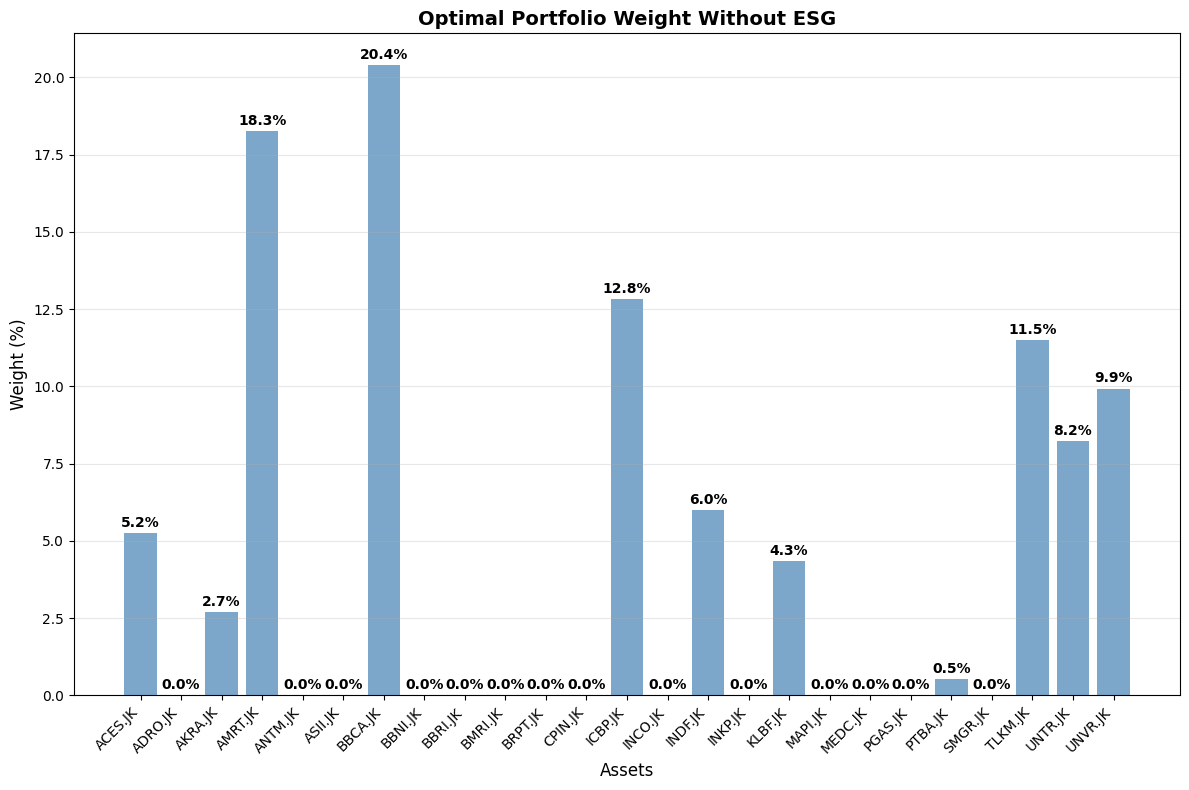

In [ ]:
import time

if __name__ == "__main__":
    print("Optimasi Portfolio PSO tanpa ESG")
    print("-" * 50)

    best_fitness = float('inf')
    best_weights = None
    best_result = None

    fitness_list = []
    waktu_list = []

    for run in range(1, 21):
        print(f"\nRun {run}/20")

        start_time = time.time()


        optimizer = PortfolioOptimizationPSO(
          mu=expected_returns.values,
          cov=cov_stock,
          theta=esg_df['ESG_Score'].values,
          stock_names=esg_df['Ticker'].values,
          mu_p_star=0.0012,   # Target expected return
          max_iter=1000,      # Target ESG
          objective='risk'
      )

        result = optimizer.optimize()
        elapsed = time.time() - start_time
        waktu_list.append(elapsed)
        fitness_list.append(result['objective_value'])

        print(f"Run {run} - Fitness: {result['objective_value']:.8f} | Time: {elapsed:.2f} sec")

        if result['objective_value'] < best_fitness:
            best_fitness = result['objective_value']
            best_weights = result['weights']
            best_result = result
            best_optimizer = optimizer

    # Statistik fitness
    fitness_array = np.array(fitness_list)
    print("\n" + "_"*70)
    print("STATISTIK FITNESS:")
    print(f"Rata-rata (Mean)   : {np.mean(fitness_array):.8f}")
    print(f"Nilai terendah (Min): {np.min(fitness_array):.8f}")
    print(f"Nilai tertinggi (Max): {np.max(fitness_array):.8f}")
    print(f"Median             : {np.median(fitness_array):.8f}")
    print(f"Variansi           : {np.var(fitness_array):.8f}")

    # Statistik waktu
    waktu_array = np.array(waktu_list)
    print("\n" + "_"*70)
    print("STATISTIK WAKTU KOMPUTASI:")
    print(f"Rata-rata waktu    : {np.mean(waktu_array):.2f} detik")
    print(f"Waktu tercepat     : {np.min(waktu_array):.2f} detik")
    print(f"Waktu terlama      : {np.max(waktu_array):.2f} detik")
    print(f"Total waktu        : {np.sum(waktu_array):.2f} detik")

    # Hasil terbaik
    print("\n\n Best Result ")
    print(f"Best Fitness: {best_fitness:.8f}")
    print("Best Weights Allocation:")
    for name, weight in zip(best_optimizer.stock_names, best_weights):
        if weight > 0.001:
            print(f"{name:<12}: {weight*100:.2f}%")

    # visualisasi dari run terbaik
    best_optimizer.print_results()
    # best_optimizer.plot_convergence()
    best_optimizer.plot_weights()


##Dengan ESG


Optimasi Portfolio PSO dengan ESG 
--------------------------------------------------

Run 1/20
Initializing PSO with 375 particles for 25 assets
Starting Enhanced Portfolio PSO optimization
Objective: Risk
Assets: 25, Particles: 375, Iterations: 1000
Target Return: 0.12%
Target ESG: ≤ 20
------------------------------------------------------------
Iter   50/1000 | Fitness: 0.000358 | Return:  0.23% | Risk:  2.68% |  | ESG: 20.00
Iter  100/1000 | Fitness: 0.000358 | Return:  0.23% | Risk:  2.68% |  | ESG: 20.00
Iter  150/1000 | Fitness: 0.000358 | Return:  0.23% | Risk:  2.68% |  | ESG: 20.00
Iter  200/1000 | Fitness: 0.000358 | Return:  0.23% | Risk:  2.68% |  | ESG: 20.00
Iter  250/1000 | Fitness: 0.000358 | Return:  0.23% | Risk:  2.68% |  | ESG: 20.00
Iter  300/1000 | Fitness: 0.000358 | Return:  0.23% | Risk:  2.68% |  | ESG: 20.00
Iter  350/1000 | Fitness: 0.000358 | Return:  0.23% | Risk:  2.68% |  | ESG: 20.00
Iter  400/1000 | Fitness: 0.000358 | Return:  0.23% | Risk:  2.68% |

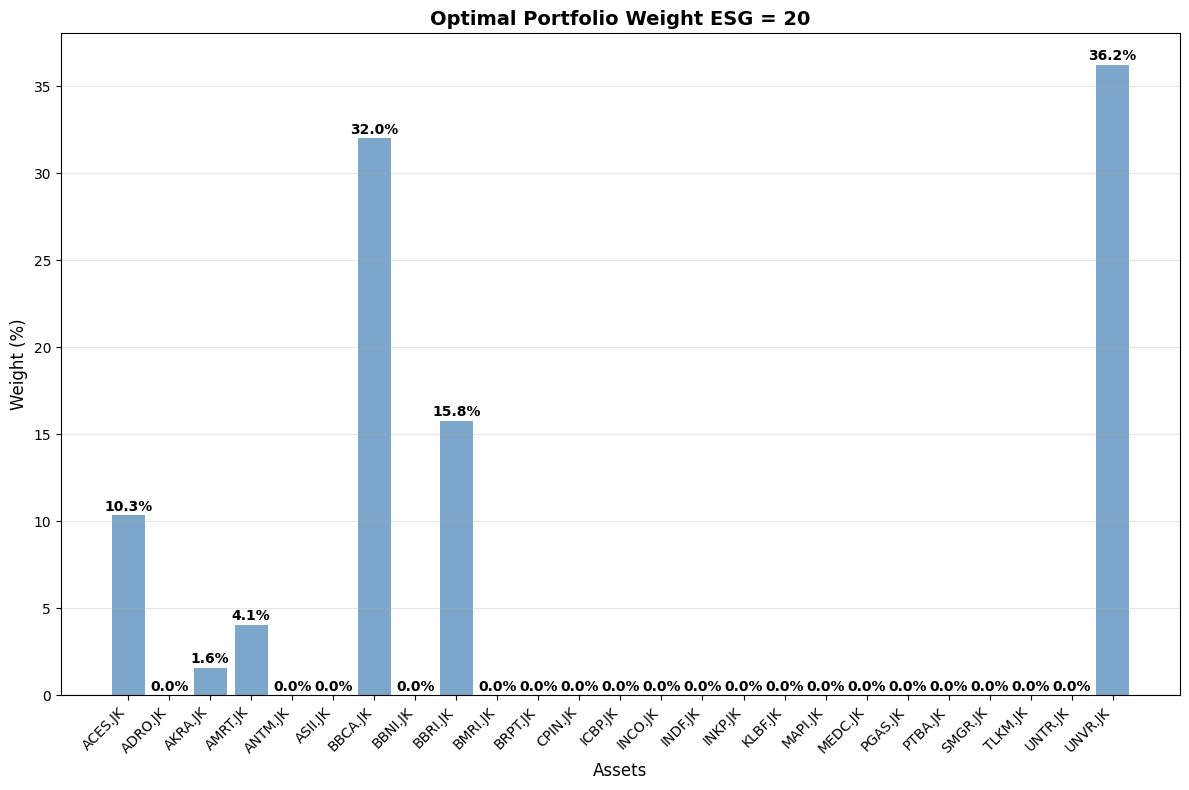

In [ ]:
import time

if __name__ == "__main__":
    print("Optimasi Portfolio PSO dengan ESG ")
    print("-" * 50)

    best_fitnessESG = 1.00
    best_weightsESG = None
    best_resultESG = None

    fitness_list = []
    waktu_list = []

    for run in range(1, 21):
        print(f"\nRun {run}/20")

        start_time = time.time()

        optimizer = PortfolioOptimizationPSO(
            mu=expected_returns.values,
            cov=cov_stock,
            theta=esg_df['ESG_Score'].values,
            stock_names=esg_df['Ticker'].values,
            mu_p_star=0.0012,    # Target expected return
            theta_p_star=20,     # Target ESG
            max_iter=1000,
            objective='risk'
        )

        resultESG = optimizer.optimize()
        elapsed = time.time() - start_time
        waktu_list.append(elapsed)
        fitness_list.append(resultESG['objective_value'])

        print(f"Run {run} - Fitness: {resultESG['objective_value']:.8f} | Time: {elapsed:.2f} sec")

        if resultESG['objective_value'] < best_fitnessESG:
            best_fitnessESG = resultESG['objective_value']
            best_weightsESG = resultESG['weights']
            best_resultESG = resultESG
            best_optimizerESG = optimizer

    # Statistik fitness
    fitness_array = np.array(fitness_list)
    print("\n" + "_"*70)
    print("STATISTIK FITNESS:")
    print(f"Rata-rata (Mean)   : {np.mean(fitness_array):.8f}")
    print(f"Nilai terendah (Min): {np.min(fitness_array):.8f}")
    print(f"Nilai tertinggi (Max): {np.max(fitness_array):.8f}")
    print(f"Median             : {np.median(fitness_array):.8f}")
    print(f"Variansi           : {np.var(fitness_array):.8f}")

    # Statistik waktu
    waktu_array = np.array(waktu_list)
    print("\n" + "_"*70)
    print("STATISTIK WAKTU KOMPUTASI:")
    print(f"Rata-rata waktu    : {np.mean(waktu_array):.2f} detik")
    print(f"Waktu tercepat     : {np.min(waktu_array):.2f} detik")
    print(f"Waktu terlama      : {np.max(waktu_array):.2f} detik")
    print(f"Total waktu        : {np.sum(waktu_array):.2f} detik")

    # Hasil terbaik
    print("\n\n Best Result ")
    print(f"Best Fitness: {best_fitnessESG:.8f}")
    print("Best Weights Allocation:")
    for name, weight in zip(best_optimizerESG.stock_names, best_weightsESG):
        if weight > 0.001:
            print(f"{name:<12}: {weight*100:.2f}%")

    # visualisasi dari run terbaik
    best_optimizerESG.print_results()
    # best_optimizer.plot_convergence()
    best_optimizerESG.plot_weights()


#Pengujian


# Revisi

In [ ]:
dataIDX30 = pd.read_csv("Data Historis IDX 30 Weekly.csv", index_col=0, parse_dates=True)
dataIDX30 = dataIDX30['Terakhir'] \
    .astype(str) \
    .str.replace(',', '.', regex=False) \
    .astype(float) \

returnsIDX30 = dataIDX30.pct_change().dropna()
idx30_cum = (1 + returnsIDX30).cumprod()

/tmp/ipython-input-1679316062.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  dataIDX30 = pd.read_csv("Data Historis IDX 30 Weekly.csv", index_col=0, parse_dates=True)


/tmp/ipython-input-3649218103.py:81: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_new_ticker = yf.download(dataTicker, start=start_date, end=end_date, interval='1wk')['Close']
[*********************100%***********************]  25 of 25 completed



📊 Rangkuman Kinerja Portofolio vs IDX30
---------------------------------------------------
                           Expected Return (%)  Risk (%)  Sharpe Ratio  \
Portfolio PSO Without ESG                17.23     11.23          0.94   
Portfolio PSO With ESG                    8.65     14.01          0.14   
IDX 30                                    1.49     13.56         -0.38   

                           Total Return (%)  
Portfolio PSO Without ESG             38.88  
Portfolio PSO With ESG                16.43  
IDX 30                                 1.19  


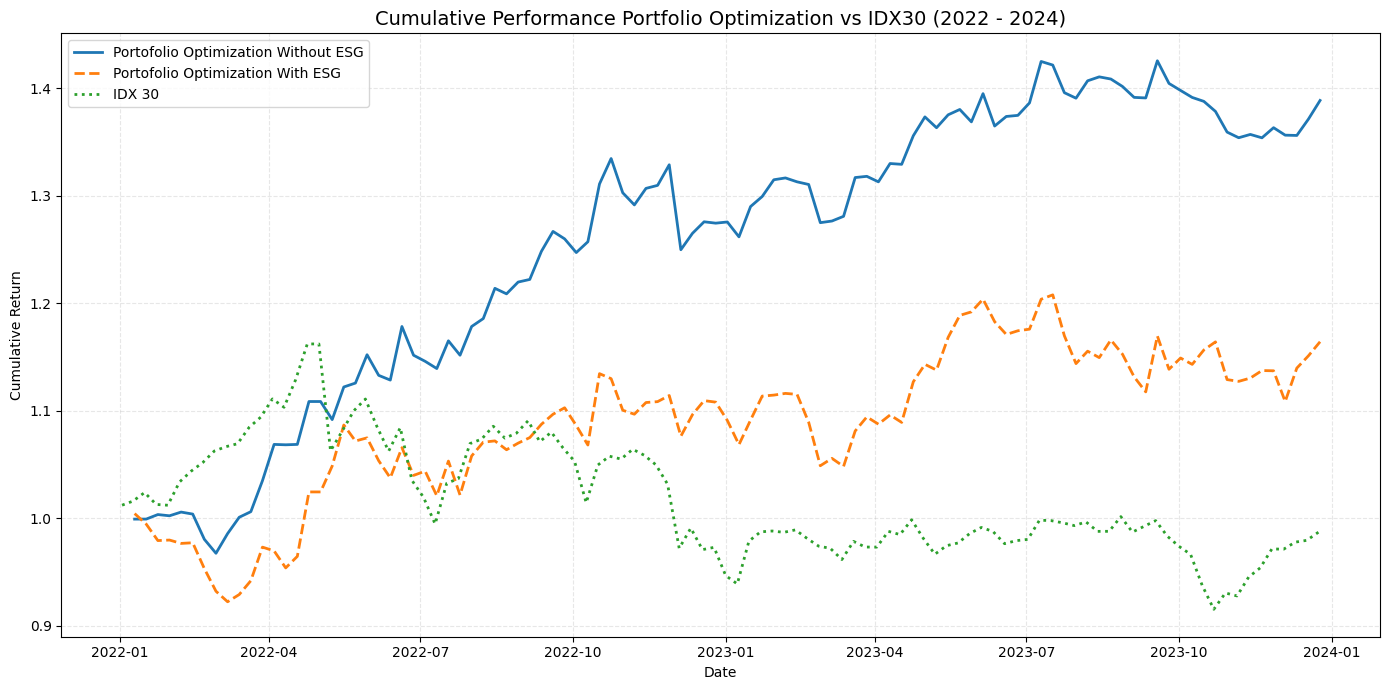

In [ ]:
start_date = '2022-01-01'
end_date = '2024-01-01'

start_date_obj = datetime.strptime(start_date, '%Y-%m-%d')
end_date_obj = datetime.strptime(end_date, '%Y-%m-%d')

tahun_start = start_date_obj.year
tahun_end = end_date_obj.year

dataTicker = [
    'ACES.JK', 'ADRO.JK', 'AKRA.JK', "AMRT.JK", "ANTM.JK",
    "ASII.JK", 'BBCA.JK', 'BBNI.JK', 'BBRI.JK', "BMRI.JK",
    'BRPT.JK', 'CPIN.JK', 'ICBP.JK', 'INCO.JK', 'INDF.JK',
    'INKP.JK', 'KLBF.JK', 'MAPI.JK', 'MEDC.JK', 'PGAS.JK',
    'PTBA.JK', 'SMGR.JK', 'TLKM.JK', 'UNTR.JK', 'UNVR.JK'
]


weights_with_esg = [
    0.1035,
    0.0,
    0.0160,
    0.0405,
    0.0,
    0.0,
    0.3200,
    0.0,
    0.1578,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.3623
]


weights_no_esg = [
    0.0524,
    0.0,
    0.0269,
    0.1828,
    0.0,
    0.0,
    0.2041,
    0.0,
    0.0,
    0.0,
    0.0,
    0.0,
    0.1284,
    0.0,
    0.0601,
    0.0,
    0.0434,
    0.0,
    0.0,
    0.0,
    0.0053,
    0.0,
    0.1151,
    0.0823,
    0.0993
]


portfolio_weights_with_esg = np.array(weights_with_esg)
portfolio_weights_no_esg = np.array(weights_no_esg)


data_new_ticker = yf.download(dataTicker, start=start_date, end=end_date, interval='1wk')['Close']
data_new_ticker = data_new_ticker.dropna()

# Hitung return mingguan
returns_new_ticker = data_new_ticker.pct_change().dropna()


returns_portfolio_with_esg = returns_new_ticker.dot(portfolio_weights_with_esg)
returns_portfolio_no_esg = returns_new_ticker.dot(portfolio_weights_no_esg)

portfolio_cum_with_esg = (1 + returns_portfolio_with_esg).cumprod()
portfolio_cum_no_esg = (1 + returns_portfolio_no_esg).cumprod()



summary = {
    'Expected Return (%)': [
        (returns_portfolio_no_esg.mean() * 52) * 100,
        (returns_portfolio_with_esg.mean() * 52) * 100,
        (returnsIDX30.mean() * 52) * 100
    ],
    'Risk (%)': [
        returns_portfolio_no_esg.std() * np.sqrt(52) * 100,
        returns_portfolio_with_esg.std() * np.sqrt(52) * 100,
        returnsIDX30.std() * np.sqrt(52) * 100
    ],
    'Sharpe Ratio': [
        ((returns_portfolio_no_esg.mean() * 52) - 0.0665) / (returns_portfolio_no_esg.std() * np.sqrt(52)),
        ((returns_portfolio_with_esg.mean() * 52) - 0.0665) / (returns_portfolio_with_esg.std() * np.sqrt(52)),
        ((returnsIDX30.mean() * 52) - 0.0665) / (returnsIDX30.std() * np.sqrt(52))
    ],
    'Total Return (%)': [
        (portfolio_cum_no_esg.iloc[-1] - 1) * 100,
        (portfolio_cum_with_esg.iloc[-1] - 1) * 100,
        (idx30_cum.iloc[-1] - 1) * 100
    ]
}

summary_df = pd.DataFrame(summary, index=[
    'Portfolio PSO Without ESG',
    'Portfolio PSO With ESG',
    'IDX 30'
])

print("\n📊 Rangkuman Kinerja Portofolio vs IDX30")
print("---------------------------------------------------")
print(summary_df.round(2))

# =============================
# 7. Visualisasi
# =============================
plt.figure(figsize=(14, 7))
plt.plot(portfolio_cum_no_esg, label='Portofolio Optimization Without ESG', linestyle='-', linewidth=2)
plt.plot(portfolio_cum_with_esg, label='Portofolio Optimization With ESG', linestyle='--',linewidth=2 )
plt.plot(idx30_cum, label='IDX 30',linestyle=':', linewidth=2)

plt.title(f'Cumulative Performance Portfolio Optimization vs IDX30 ({tahun_start} - {tahun_end})', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
